# Анализ лояльности пользователей Яндекс Афиши

### Цели и задачи проекта

<font color='#777778'>**Цель:** Провести исследовательский анализ данных лояльности пользователей сервиса "Яндекс Афиша", чтобы понять, какие пользователи с большей вероятностью возвращаются на платформу и делают заказы повторно.   

**Задачи:**
1. Загрузить данные и познакомиться с их содержимым.
2. Провести предобработку данных.
3. Описать профиль пользователя
4. Исследовать признаки, влияющие на совершение повторного заказа пользователями.
5. Сформулировать общий вывод и рекомендации

</font>

## Содержимое проекта
#### Оглавление

1. <a href="#section1">Загрузка данных</a>
2. <a href="#section2">Предобработка данных</a>
3. <a href="#section3">Создание профиля пользователя</a>
4. <a href="#section4">Исследовательский анализ данных</a>
    
    4.1 <a href="#section41">Исследование признаков первого заказа и их связи с возвращением на платформу</a>
    
    4.2 <a href="#section42">Исследование поведения пользователей через показатели выручки и состава заказа</a>
    
    4.3 <a href="#section43">Исследование временных характеристик первого заказа и их влияния на повторные покупки</a>
    
    4.4 <a href="#section44">Корреляционный анализ количества покупок и признаков пользователя</a>

5. <a href="#section5">Выводы и рекомендации</a>
---

<a id="section1"></a>

## Этапы выполнения проекта

### 1. Загрузка данных и их предобработка
---

**Задача 1.1:** Напишите SQL-запрос, выгружающий в датафрейм pandas необходимые данные. 

<u>Параметры для подключения к базе данных заданы в connection.env</u>

Для выгрузки используйте запрос из предыдущего урока и библиотеку SQLAlchemy.

Выгрузка из базы данных SQL должна позволить собрать следующие данные:

- `user_id` — уникальный идентификатор пользователя, совершившего заказ;
- `device_type_canonical` — тип устройства, с которого был оформлен заказ (`mobile` — мобильные устройства, `desktop` — стационарные);
- `order_id` — уникальный идентификатор заказа;
- `order_dt` — дата создания заказа (используйте данные `created_dt_msk`);
- `order_ts` — дата и время создания заказа (используйте данные `created_ts_msk`);
- `currency_code` — валюта оплаты;
- `revenue` — выручка от заказа;
- `tickets_count` — количество купленных билетов;
- `days_since_prev` — количество дней от предыдущей покупки пользователя, для пользователей с одной покупкой — значение пропущено;
- `event_id` — уникальный идентификатор мероприятия;
- `service_name` — название билетного оператора;
- `event_type_main` — основной тип мероприятия (театральная постановка, концерт и так далее);
- `region_name` — название региона, в котором прошло мероприятие;
- `city_name` — название города, в котором прошло мероприятие.

---


In [1]:
# Импортируем необходимые библиотеки

import pandas as pd

from sqlalchemy import create_engine

from dotenv import load_dotenv

import os

import matplotlib.pyplot as plt

import numpy as np

import seaborn as sns

import phik
from phik.report import plot_correlation_matrix

In [2]:
# Загрузка переменных из connetion.env
load_dotenv(dotenv_path='connection.env')

host = os.getenv('HOST')
database = os.getenv('DATABASE')
port = os.getenv('PORT')
auth = os.getenv('AUTH')
user = os.getenv('USER')
password = os.getenv('PASSWORD')

In [3]:
# Создаем config для подключения
db_config = {'user': user, 
             'pwd': password, 
             'host': host,
             'port': port, 
             'db': database
             }

# Формируем строку к подключению
connection_string = 'postgresql://{}:{}@{}:{}/{}'.format(
    db_config['user'],
    db_config['pwd'],
    db_config['host'],
    db_config['port'],
    db_config['db'],
)

# Создаем подключение
engine = create_engine(connection_string)

In [4]:
# Формируем запрос к данным
query = '''
WITH set_config_precode AS (
  SELECT set_config('synchronize_seqscans', 'off', true)
)

select 
  user_id,
  p.device_type_canonical,
  p.order_id,
  p.created_dt_msk AS order_dt,
  p.created_ts_msk AS order_ts,
  p.currency_code,
  p.revenue,
  p.tickets_count,
	cast(p.created_dt_msk as date)- cast(LAG(p.created_dt_msk ) over (partition by p.user_id  order by p.created_dt_msk) as date) as days_since_prev,
  p.event_id,
  p.service_name,
  e.event_type_main,
  r.region_name,
  c.city_name
from afisha.purchases p
left join afisha.events as e ON p.event_id=e.event_id
left join afisha.city as c ON e.city_id=c.city_id
left join afisha.regions as r ON c.region_id=r.region_id
where 
  (p.device_type_canonical = 'mobile' 
  OR p.device_type_canonical = 'desktop')
  AND e.event_type_main != 'фильм'
order BY p.user_id
'''

In [5]:
# Создаем датафрейм для работы
df = pd.read_sql_query(query, con=engine)

In [6]:
df.head(10)

,user_id,device_type_canonical,order_id,order_dt,order_ts,currency_code,revenue,tickets_count,days_since_prev,event_id,service_name,event_type_main,region_name,city_name
0,0002849b70a3ce2,mobile,4359165,2024-08-20,2024-08-20 16:08:03,rub,1521.94,4,NaN,169230,Край билетов,театр,Каменевский регион,Глиногорск
1,0005ca5e93f2cf4,mobile,7965605,2024-07-23,2024-07-23 18:36:24,rub,289.45,2,NaN,237325,Мой билет,выставки,Каменевский регион,Глиногорск
2,0005ca5e93f2cf4,mobile,7292370,2024-10-06,2024-10-06 13:56:02,rub,1258.57,4,75.0,578454,За билетом!,другое,Каменевский регион,Глиногорск
3,000898990054619,mobile,1139875,2024-07-13,2024-07-13 19:40:48,rub,8.49,2,NaN,387271,Лови билет!,другое,Североярская область,Озёрск
4,000898990054619,mobile,972400,2024-10-04,2024-10-04 22:33:15,rub,1390.41,3,83.0,509453,Билеты без проблем,стендап,Озернинский край,Родниковецк
5,000898990054619,mobile,2613713,2024-10-23,2024-10-23 15:12:00,rub,902.74,3,19.0,500862,Облачко,концерты,Лугоградская область,Кристалевск
6,00096d1f542ab2b,desktop,6636941,2024-08-15,2024-08-15 16:48:48,rub,917.83,4,NaN,201953,Край билетов,театр,Каменевский регион,Глиногорск
7,000a55a418c128c,mobile,4657981,2024-09-29,2024-09-29 19:39:12,rub,47.78,1,NaN,265857,Лучшие билеты,театр,Поленовский край,Дальнозолотск
8,000a55a418c128c,mobile,4657952,2024-10-15,2024-10-15 10:29:04,rub,74.84,2,16.0,271579,Лучшие билеты,театр,Поленовский край,Дальнозолотск
9,000cf0659a9f40f,mobile,6818017,2024-06-20,2024-06-20 10:35:26,rub,1421.91,4,NaN,516728,Лови билет!,концерты,Широковская область,Радужнополье


In [7]:
# Cоздаем копию датасета до преобразования для возможности проверить сделанные изменения после предобработки
temp = df.copy() 
len_original_df = len(temp)

---

**Задача 1.2:** Изучите общую информацию о выгруженных данных. Оцените корректность выгрузки и объём полученных данных.

Предположите, какие шаги необходимо сделать на стадии предобработки данных — например, скорректировать типы данных.

Зафиксируйте основную информацию о данных в кратком промежуточном выводе.

---

In [8]:
# Разработаем класс по просмотру датафрейма и разыне методы для анализа
class DataFrameReporter:
    
    def __init__(self, dataframe):
        self.df = dataframe
    
    def show_total_report(self, title=None):
        if title:
            print(title)
        
        self.df.info()

        print('Количество столбцов:', self.df.shape[1])
        print('Количество строк:', self.df.shape[0])

        duplicates = self.df.duplicated().sum()
        print('Количество дубликатов:', duplicates)

        # Защита от деления на ноль
        if self.df.shape[0] > 0:
            print('Доля дубликатов:', duplicates / self.df.shape[0])
        else:
            print('Доля дубликатов: нет строк')

        print('Количество пропусков:', self.df.isna().sum().sum())
        
        print(f'Доля пропусков: {round(self.df.isna().sum().sum() / len(self.df)*100, 2)}')
    
    def show_unique(self, column):
        unique_vals = self.df[column].sort_values().unique().tolist()
        print(f'Уникальные записи для поля {column}:\n{unique_vals}')

    
    def show_describe(self, column=None):
        if column is not None:
            if column not in self.df.columns:
                raise KeyError(f"Столбец '{column}' не найден")
            print(self.df[column].describe())
        else:
            print(self.df.describe())
    
    def show_histogram(self, column, bins=10, title=None, xlabel=None, lg=False):
        plt.figure(figsize=(12,8))
        plt.hist(self.df[column], bins=bins, alpha=1, color='salmon', edgecolor='black')
        plt.title(title) 
        plt.xlabel(xlabel)
        plt.ylabel('Частота')
        plt.grid(True)
        if lg: plt.yscale('log')
        plt.show()

    def show_boxplot(self, column, title=None, xlabel=None):
        plt.figure(figsize=(12,8))
        plt.boxplot(self.df[column], vert=False, flierprops=dict(markerfacecolor='red', marker='o'))
        plt.title(title)
        plt.xlabel(xlabel)
        plt.grid(True)
        plt.show()

    def show_diagramm(self, Xcolumn, YColumn, kind='barh', rot=0, legend=False, title=None, xlabel=None, ylabel=None):
        if kind == 'barh':
            plt.barh(self.df[YColumn], self.df[Xcolumn],
                    color='xkcd:sky blue', edgecolor='black')
        else:
            self.df.plot(x=Xcolumn, y=YColumn, kind=kind, rot=rot, legend=legend, 
                        color='xkcd:sky blue', edgecolor='black')
        plt.xlabel(xlabel)
        plt.ylabel(ylabel)
        plt.title(title)
        plt.grid()
        plt.show()   

In [9]:
# Создаем экземпрляр класса
df_reporter = DataFrameReporter(df)

# Посмотрим на общий отчет
df_reporter.show_total_report(title='Исходный датафрейм')


Исходный датафрейм
<class 'pandas.DataFrame'>
RangeIndex: 290611 entries, 0 to 290610
Data columns (total 14 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   user_id                290611 non-null  str           
 1   device_type_canonical  290611 non-null  str           
 2   order_id               290611 non-null  int64         
 3   order_dt               290611 non-null  datetime64[us]
 4   order_ts               290611 non-null  datetime64[us]
 5   currency_code          290611 non-null  str           
 6   revenue                290611 non-null  float64       
 7   tickets_count          290611 non-null  int64         
 8   days_since_prev        268678 non-null  float64       
 9   event_id               290611 non-null  int64         
 10  service_name           290611 non-null  str           
 11  event_type_main        290611 non-null  str           
 12  region_name            290611 non-nu

In [10]:
# Первичный анализ данных
count_first_order = df['days_since_prev'].isna().sum()
print(f"""
Количество уникальных пользователей: {df['user_id'].nunique()}
Количество первых заказов: {count_first_order}
Количество уникальных заказов: {df['order_id'].nunique()}
Доля первых заказов составляет: {round(count_first_order/len(df)*100,2)}
Количество заказов с выручкой равно 0 составляет: {len(df[df['revenue'] == 0])} или {round(len(df[df['revenue'] == 0])/len(df)*100,2)}%
Количество заказов с выручкой ниже 0 составляет: {len(df[df['revenue'] < 0])} или {round(len(df[df['revenue'] < 0])/len(df)*100,2)}%
""")


Количество уникальных пользователей: 21933
Количество первых заказов: 21933
Количество уникальных заказов: 290611
Доля первых заказов составляет: 7.55
Количество заказов с выручкой равно 0 составляет: 5526 или 1.9%
Количество заказов с выручкой ниже 0 составляет: 381 или 0.13%



In [11]:
df_reporter.show_unique('device_type_canonical')
df_reporter.show_unique('event_type_main')
df_reporter.show_unique('currency_code')

Уникальные записи для поля device_type_canonical:
['desktop', 'mobile']
Уникальные записи для поля event_type_main:
['выставки', 'другое', 'концерты', 'спорт', 'стендап', 'театр', 'ёлки']
Уникальные записи для поля currency_code:
['kzt', 'rub']


##### Промежуточный вывод

* Всего в датафрейме содержится 290611 строк, пропуски встречаются только в столбце `days_since_prev`, который был добавлен на этапе формирования данных (SQL запроса). Значение NULL в данном столбце означает, что это первый заказ покупателя.
* Количество заказов равно количеству строк датафрейма. Таким образом, `orer_id` уникально для каждой строки датафрейма и является первичным ключом.
* Количество первых заказов равно количеству уникальных пользователей. 
* Доля первых заказов составляет 7,55% от общего количества заказов. Таким образом, более 90% строк датафрейма это повторные заказы.
* Столбец `device_type_canonical` имеет тип str. Однако в датафрейме встречается всего 2 значения: 'desktop' и 'mobile'. Можно преобразовать к категориальному типу.
* Столбец `order_id` имеет тип int64, хотя максимальное значение составляет 8'653'108 - можно понизить до uint32, так как нет отрицательных значений.
* Столбец `order_dt` имеет тип datetime64, при этом анализ показывает, что в данном столбце время не указана, только дата. Таким образом, можно привести к типу date.
* В столбце `currency_code` содержится только 2 кода валюты: рубль и казахстанский тенге. Таким образом, необходимо учмитывать код валюты при анализе столбца `revenue`
* Столбец `revenue` имеет тип float64 - можно понизить до float32
* В столбце `revenue` содержатся значения равные 0 (~1,9% от всех данных) и отрицательные значения (~0,13%). Учитывая, что данный столбец отражает выручку от продажи билетов, то можно предположить, что заказы с нулевой выручкой это билеты на бесплатное мероприятие или билеты, например, по промокоду или по какой-то акции. Заказы с отрицательной выручкой могут говорить о том, что это возврат ранее купленных билетов, то есть для возврата оформляется отдельный заказ. Но это так же может быть и технической ошибкой. Для корректного вывода необходимо провести дополнительный анализ.
* Столбец `tickets_count` имеет тип int64. При этом в данном поле значения  содержаться от 1 до 57, отрицательные значения отсутствуют. Можно преобразовать к типу uint8 (беззнаковое 8-битное целое).
* Столбец `days_since_prev` имеет тип float64, однако значения встречаются в диапазоне от 0 до 148. Поскольку в данном столбце встречаются значения NULL, то можно преобразовать к типу UInt8 (nullable-тип pandas).
* Столбец `event_id` имеет тип int64 можно преобразовать к uint32, отрицательных значений нет.
* Столбец `event_type_main` содержит значения: 'выставки', 'другое', 'концерты', 'спорт', 'стендап', 'театр', 'ёлки'. Можно преобразовать к категориальному типу данных, вместо str
* Столбцы `service_name`, `region_name` и `city_name` могут содержать неявные дубликаты - необходимо проверить на этапе предобработки данных.

Таким образом, данные датафрейма корректны.

<a id="section2"></a>
---

###  2. Предобработка данных

Выполните все стандартные действия по предобработке данных:

---

**Задача 2.1:** Данные о выручке сервиса представлены в российских рублях и казахстанских тенге. Приведите выручку к единой валюте — российскому рублю.

Для этого используйте датасет с информацией о курсе казахстанского тенге по отношению к российскому рублю за 2024 год — `final_tickets_tenge_df.csv`. Его можно загрузить по пути `https://code.s3.yandex.net/datasets/final_tickets_tenge_df.csv')`

Значения в рублях представлено для 100 тенге.

Результаты преобразования сохраните в новый столбец `revenue_rub`.

---


In [12]:
# Получим данные о курсе рубля и тенге
df_curr_rates = pd.read_csv('https://code.s3.yandex.net/datasets/final_tickets_tenge_df.csv')

df_curr_rates_reporter = DataFrameReporter(df_curr_rates)
df_curr_rates_reporter.show_total_report(title='Датафрейм о курсах валют')

Датафрейм о курсах валют
<class 'pandas.DataFrame'>
RangeIndex: 357 entries, 0 to 356
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   data     357 non-null    str    
 1   nominal  357 non-null    int64  
 2   curs     357 non-null    float64
 3   cdx      357 non-null    str    
dtypes: float64(1), int64(1), str(2)
memory usage: 11.3 KB
Количество столбцов: 4
Количество строк: 357
Количество дубликатов: 0
Доля дубликатов: 0.0
Количество пропусков: 0
Доля пропусков: 0.0


In [13]:
df_curr_rates.head(10)

,data,nominal,curs,cdx
0,2024-01-10,100,19.9391,kzt
1,2024-01-11,100,19.7255,kzt
2,2024-01-12,100,19.5839,kzt
3,2024-01-13,100,19.4501,kzt
4,2024-01-14,100,19.4501,kzt
5,2024-01-15,100,19.4501,kzt
6,2024-01-16,100,19.4264,kzt
7,2024-01-17,100,19.4177,kzt
8,2024-01-18,100,19.5798,kzt
9,2024-01-19,100,19.5741,kzt


In [14]:
# Преобразуем столбец `data` из str в date
df_curr_rates['data'] = pd.to_datetime(df_curr_rates['data'])

In [15]:
#Проверим уникальность поля `data`
df_curr_rates['data'].nunique()

357

In [16]:
#Отберем в исходном датафрейме все строки у которых валюта kzt
df_kzt = df[df['currency_code']=='kzt']

df_kzt_reporter = DataFrameReporter(df_kzt)
df_kzt_reporter.show_total_report(title='Датафрейм с заказами в тенге')

Датафрейм с заказами в тенге
<class 'pandas.DataFrame'>
Index: 5069 entries, 70 to 290489
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   user_id                5069 non-null   str           
 1   device_type_canonical  5069 non-null   str           
 2   order_id               5069 non-null   int64         
 3   order_dt               5069 non-null   datetime64[us]
 4   order_ts               5069 non-null   datetime64[us]
 5   currency_code          5069 non-null   str           
 6   revenue                5069 non-null   float64       
 7   tickets_count          5069 non-null   int64         
 8   days_since_prev        4195 non-null   float64       
 9   event_id               5069 non-null   int64         
 10  service_name           5069 non-null   str           
 11  event_type_main        5069 non-null   str           
 12  region_name            5069 non-null   str    

Получили 5069 записей

In [17]:
# Объединеним датафрейм с заказами в тенге и курсами валюты, переведем тенге в рубли
df_merge_kzt = df_kzt.merge(df_curr_rates, left_on='order_dt', right_on='data', how='left')
df_merge_kzt['revenue_rub'] = round(df_merge_kzt['revenue'] * df_merge_kzt['curs'] / 100, 2)

df_merge_kzt_reporter = DataFrameReporter(df_merge_kzt)
df_merge_kzt_reporter.show_total_report(title='Датафрейм о курсах валют')

Датафрейм о курсах валют
<class 'pandas.DataFrame'>
RangeIndex: 5069 entries, 0 to 5068
Data columns (total 19 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   user_id                5069 non-null   str           
 1   device_type_canonical  5069 non-null   str           
 2   order_id               5069 non-null   int64         
 3   order_dt               5069 non-null   datetime64[us]
 4   order_ts               5069 non-null   datetime64[us]
 5   currency_code          5069 non-null   str           
 6   revenue                5069 non-null   float64       
 7   tickets_count          5069 non-null   int64         
 8   days_since_prev        4195 non-null   float64       
 9   event_id               5069 non-null   int64         
 10  service_name           5069 non-null   str           
 11  event_type_main        5069 non-null   str           
 12  region_name            5069 non-null   str      

Все строки обработались, значит курсы тенге были для каждой даты, которая встречается в таблице с заказами

In [18]:
#Добавим в исходный датафрейм новое поле 'revenue_rub'
df = df.merge(df_merge_kzt[['order_id', 'revenue_rub']], on='order_id', how='left')

#Пропущенные значения нового поля (те заказы, где валюта рубли) заполним значением из поля поля 'revenue'.
df['revenue_rub']=df['revenue_rub'].fillna(df['revenue'])

df_reporter = DataFrameReporter(df)
df_reporter.show_total_report()

<class 'pandas.DataFrame'>
RangeIndex: 290611 entries, 0 to 290610
Data columns (total 15 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   user_id                290611 non-null  str           
 1   device_type_canonical  290611 non-null  str           
 2   order_id               290611 non-null  int64         
 3   order_dt               290611 non-null  datetime64[us]
 4   order_ts               290611 non-null  datetime64[us]
 5   currency_code          290611 non-null  str           
 6   revenue                290611 non-null  float64       
 7   tickets_count          290611 non-null  int64         
 8   days_since_prev        268678 non-null  float64       
 9   event_id               290611 non-null  int64         
 10  service_name           290611 non-null  str           
 11  event_type_main        290611 non-null  str           
 12  region_name            290611 non-null  str           


---

**Задача 2.2:**

- Проверьте данные на пропущенные значения. Если выгрузка из SQL была успешной, то пропуски должны быть только в столбце `days_since_prev`.
- Преобразуйте типы данных в некоторых столбцах, если это необходимо. Обратите внимание на данные с датой и временем, а также на числовые данные, размерность которых можно сократить.
- Изучите значения в ключевых столбцах. Обработайте ошибки, если обнаружите их.
    - Проверьте, какие категории указаны в столбцах с номинальными данными. Есть ли среди категорий такие, что обозначают пропуски в данных или отсутствие информации? Проведите нормализацию данных, если это необходимо.
    - Проверьте распределение численных данных и наличие в них выбросов. Для этого используйте статистические показатели, гистограммы распределения значений или диаграммы размаха.
        
        Важные показатели в рамках поставленной задачи — это выручка с заказа (`revenue_rub`) и количество билетов в заказе (`tickets_count`), поэтому в первую очередь проверьте данные в этих столбцах.
        
        Если обнаружите выбросы в поле `revenue_rub`, то отфильтруйте значения по 99 перцентилю.

После предобработки проверьте, были ли отфильтрованы данные. Если были, то оцените, в каком объёме. Сформулируйте промежуточный вывод, зафиксировав основные действия и описания новых столбцов.

---

In [19]:
# Приведем столбцы к нужному типу данных.
df[['device_type_canonical', 'event_type_main']] = df[['device_type_canonical', 'event_type_main']].astype('category')
df[['order_id', 'event_id']] = df[['order_id', 'event_id']].astype('uint32')
df[['revenue', 'revenue_rub']] = df[['revenue', 'revenue_rub']].astype('float32')
df['tickets_count'] = df['tickets_count'].astype('uint8')
df['days_since_prev'] = df['days_since_prev'].astype('UInt8')
df['order_dt'] = df['order_dt'].dt.date

In [20]:
df_reporter.show_total_report()

<class 'pandas.DataFrame'>
RangeIndex: 290611 entries, 0 to 290610
Data columns (total 15 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   user_id                290611 non-null  str           
 1   device_type_canonical  290611 non-null  category      
 2   order_id               290611 non-null  uint32        
 3   order_dt               290611 non-null  object        
 4   order_ts               290611 non-null  datetime64[us]
 5   currency_code          290611 non-null  str           
 6   revenue                290611 non-null  float32       
 7   tickets_count          290611 non-null  uint8         
 8   days_since_prev        268678 non-null  UInt8         
 9   event_id               290611 non-null  uint32        
 10  service_name           290611 non-null  str           
 11  event_type_main        290611 non-null  category      
 12  region_name            290611 non-null  str           


Задание: Проверьте, какие категории указаны в столбцах с номинальными данными. Есть ли среди категорий такие, что обозначают пропуски в данных или отсутствие информации? Проведите нормализацию данных, если это необходимо.

In [21]:
df_reporter.show_unique('device_type_canonical')
df_reporter.show_unique('event_type_main')

Уникальные записи для поля device_type_canonical:
['desktop', 'mobile']
Уникальные записи для поля event_type_main:
['выставки', 'другое', 'концерты', 'спорт', 'стендап', 'театр', 'ёлки']


Данные корректны, дополнительная обработка не требуется.

In [22]:
# Приведем столбцы с текстом к нижнему регистру
cols = ['service_name', 'region_name', 'city_name']
for col in cols:
    df[col] = df[col].str.lower()

Задание: 
Проверьте распределение численных данных и наличие в них выбросов. Для этого используйте статистические показатели, гистограммы распределения значений или диаграммы размаха. 
Важные показатели в рамках поставленной задачи — это выручка с заказа (`revenue_rub`) и количество билетов в заказе (`tickets_count`), поэтому в первую очередь проверьте данные в этих столбцах. 
Если обнаружите выбросы в поле `revenue_rub`, то отфильтруйте значения по 99 перцентилю.

In [23]:
#Проверим данные на неполные дубликаты по коду пользователя и времени создания заказа
unique_cols = ['user_id', 'order_ts']
duplicates = df.duplicated(subset=unique_cols, keep=False)

# Создаём новый датафрейм только из строк-дубликатов
duplicates_df = df[duplicates].copy()

# посмотрим на дубликаты
print(f"Всего строк в исходном датафрейме: {len(df)}")
print(f"Найдено строк-дубликатов: {len(duplicates_df)}")
print(f"Из них уникальных комбинаций (user_id, order_ts) с дублями: {duplicates_df[unique_cols].nunique()}")

# Показываем первые 20 несколько дубликатов
print("\nПервые 20 строк дубликатов:")
print(duplicates_df[['user_id', 'order_ts', 'tickets_count', 'revenue_rub']].head(20))


Всего строк в исходном датафрейме: 290611
Найдено строк-дубликатов: 325
Из них уникальных комбинаций (user_id, order_ts) с дублями: user_id      91
order_ts    155
dtype: int64

Первые 20 строк дубликатов:
               user_id            order_ts  tickets_count  revenue_rub
4350   02ea4583333f064 2024-08-23 22:46:05              3    89.610001
4353   02ea4583333f064 2024-08-23 22:46:05              2    59.740002
5687   02ea4583333f064 2024-10-16 17:49:44              2   651.539978
5714   02ea4583333f064 2024-10-16 17:49:44              2   976.169983
6067   02ea4583333f064 2024-10-27 16:39:40              2   752.510010
6069   02ea4583333f064 2024-10-27 16:39:40              4   499.450012
11759  06eb7897f65b433 2024-08-13 16:31:07              1    69.820000
11760  06eb7897f65b433 2024-08-13 16:31:07              1    69.820000
12676  08199117318954f 2024-07-31 11:52:06              3     0.000000
12677  08199117318954f 2024-07-31 11:52:06              3     0.000000
14019  0ae42a

In [24]:
# Избавляемся от дубликатов
df = df.drop_duplicates(subset=['user_id', 'order_ts'], keep='first')
df_reporter = DataFrameReporter(df)

In [25]:
# Проверим сколько строк датафрейма осталось от исходного датафрейма
a, b = len(temp), len(df)
print(a, b, a-b, round((a-b)/a*100, 2))

290611 290441 170 0.06


Процент потерь после избавления от дубликатов составил 0,06% - не критично

In [26]:
# Проанализируем статистические показатели поля `reveue_rub`
df_reporter.show_describe('revenue_rub')

count    290441.000000
mean        555.698425
std         875.656799
min         -90.760002
25%         113.970001
50%         351.299988
75%         802.049988
max       81174.539062
Name: revenue_rub, dtype: float64


Анализ показывает, что среднее значние сильно отличается от медианы (50 перцентиль), а также довольно высокое стандартное отклонение, что говорит о наличии в данных выбросов. Также, как было отмечено ранее, в данных встречается отрицательное значение и значение равное 0, что может говорить о том, что это могут быть возвраты билетов либо продажи билетов, например, по промокоду, то есть выручка по ним равна 0.

In [27]:
# Уберем отрицательные значения из revenue_rub
df['revenue_rub'] = df['revenue'].where(df['revenue_rub'] >= 0)
df.dropna(subset=['revenue_rub'], inplace=True)

# Заново инициализируем экземпляр DataFrameReporter
df_reporter = DataFrameReporter(df)
df_reporter.show_describe('revenue_rub')

# Проверим сколько строк датафрейма осталось от исходного датафрейма
a, b = len(temp), len(df)
print(a, b, a-b, round((a-b)/a*100, 2))

count    290062.000000
mean        626.510925
std        1228.289307
min           0.000000
25%         116.989998
50%         357.089996
75%         810.409973
max       81174.539062
Name: revenue_rub, dtype: float64
290611 290062 549 0.19


После избавления от отрицательной выручки потеря данных составила 0,19% от исходного датафрейма. Менее 1%, допустимая корректировка. 

In [28]:
# Проанализируем статистические показатели поля `reveue_rub`
df_reporter.show_describe('tickets_count')

count    290062.000000
mean          2.755194
std           1.170650
min           1.000000
25%           2.000000
50%           3.000000
75%           4.000000
max          57.000000
Name: tickets_count, dtype: float64


Анализ показывает, что по столбцу есть выбросы, так как 75 перценитиль это 4 купленых билета, а максимальное значение составляет 57 билетов. 

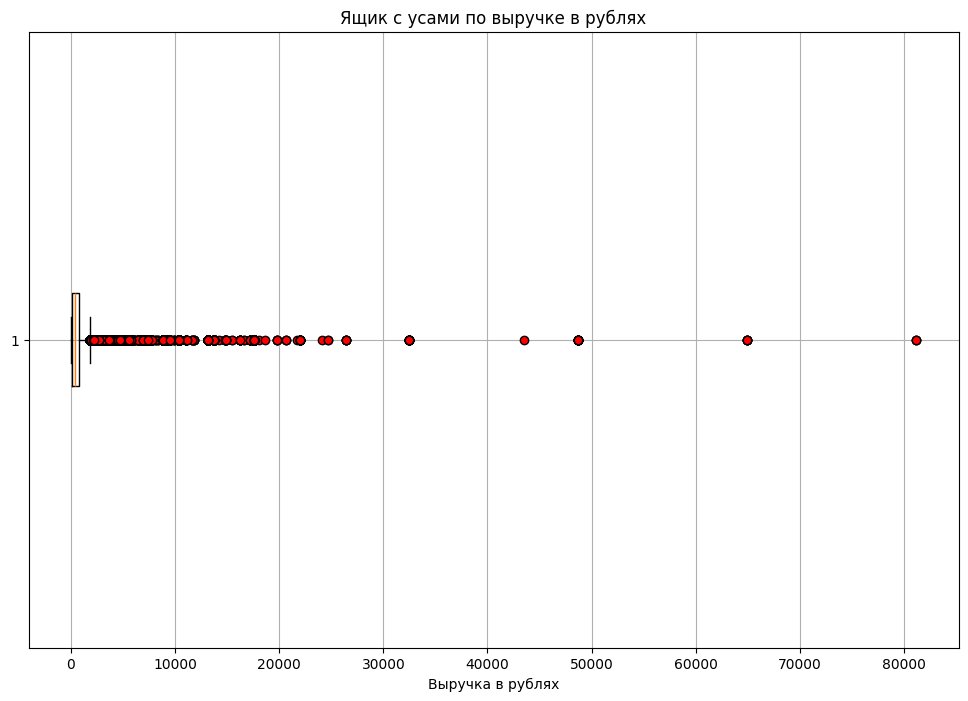

In [29]:
# Построим "ящик с усами" по 'revenue_rub'
df_reporter.show_boxplot('revenue_rub', 'Ящик с усами по выручке в рублях', 'Выручка в рублях')

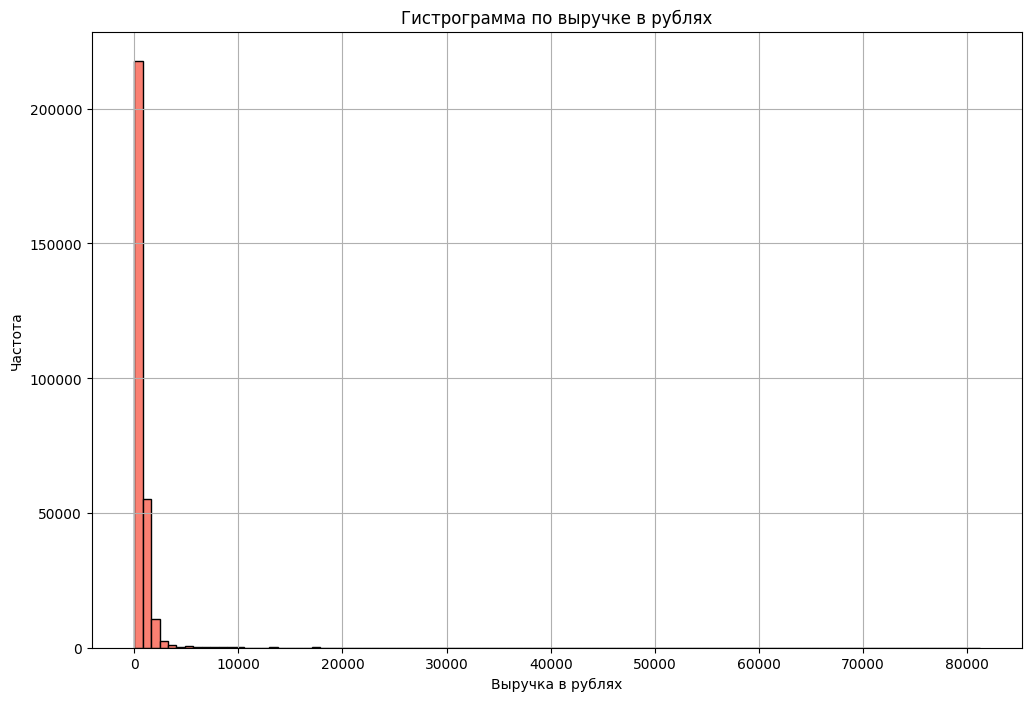

In [30]:
# Построим гистрограмму по 'revenue_rub'
df_reporter.show_histogram('revenue_rub',
                           100,
                           'Гистрограмма по выручке в рублях',
                           'Выручка в рублях')

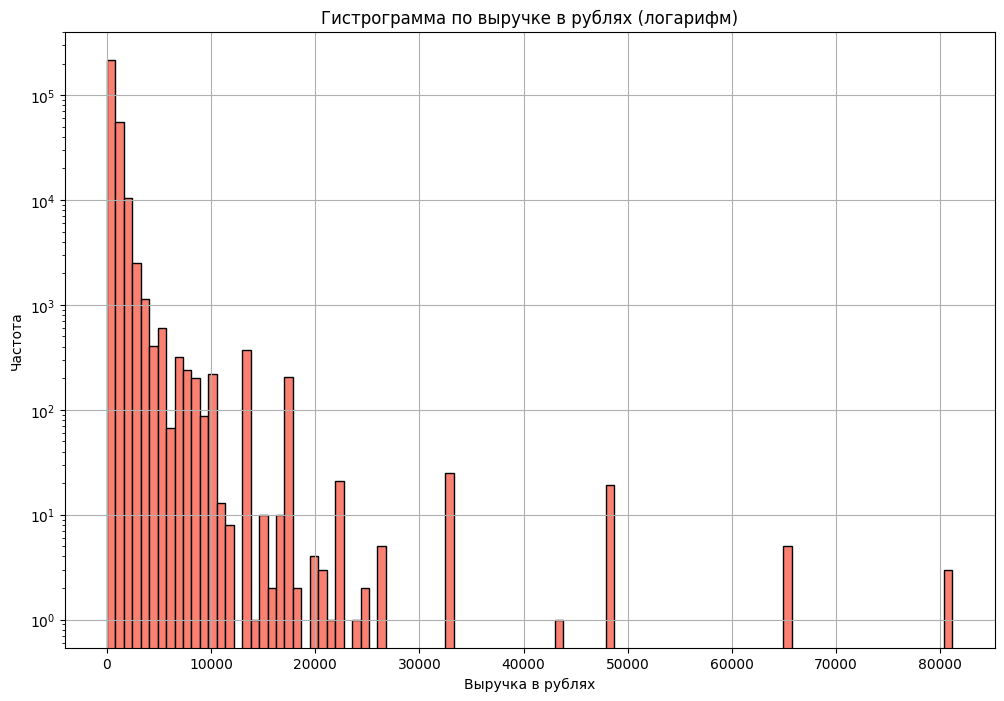

In [31]:
# Построим гистрограмму по 'revenue_rub'используя логарифмическую шкалу для нагладности
df_reporter.show_histogram('revenue_rub',
                           100,
                           'Гистрограмма по выручке в рублях (логарифм)',
                           'Выручка в рублях',
                           True)


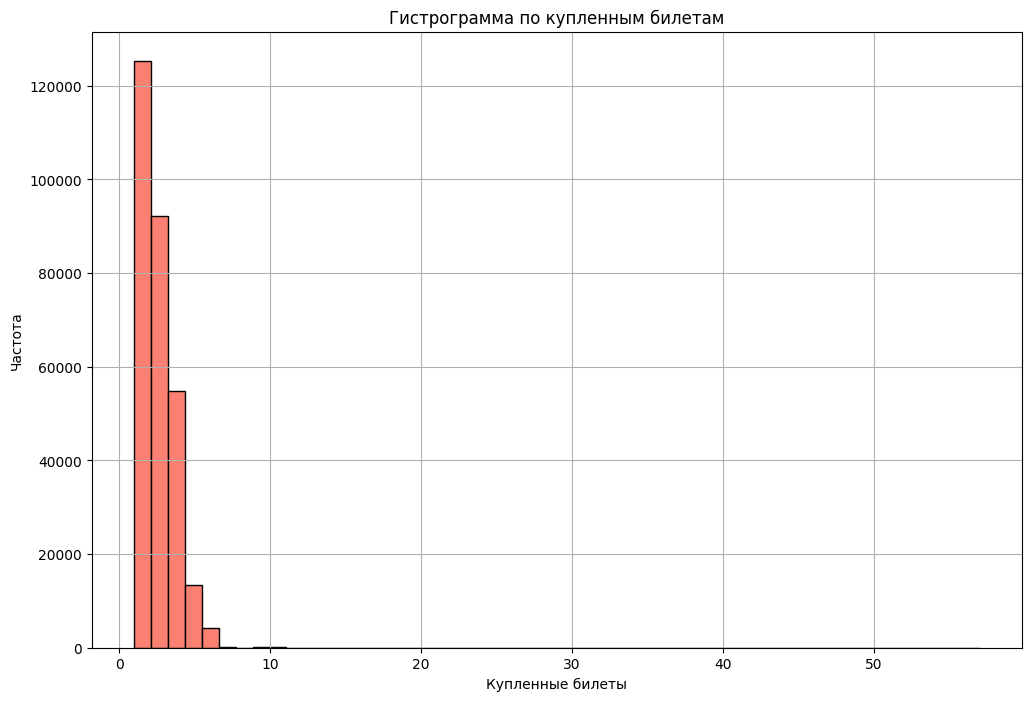

In [32]:
# Построим гистрограмму по 'tickets_count'
df_reporter.show_histogram('tickets_count',
                           50,
                           'Гистрограмма по купленным билетам',
                           'Купленные билеты')

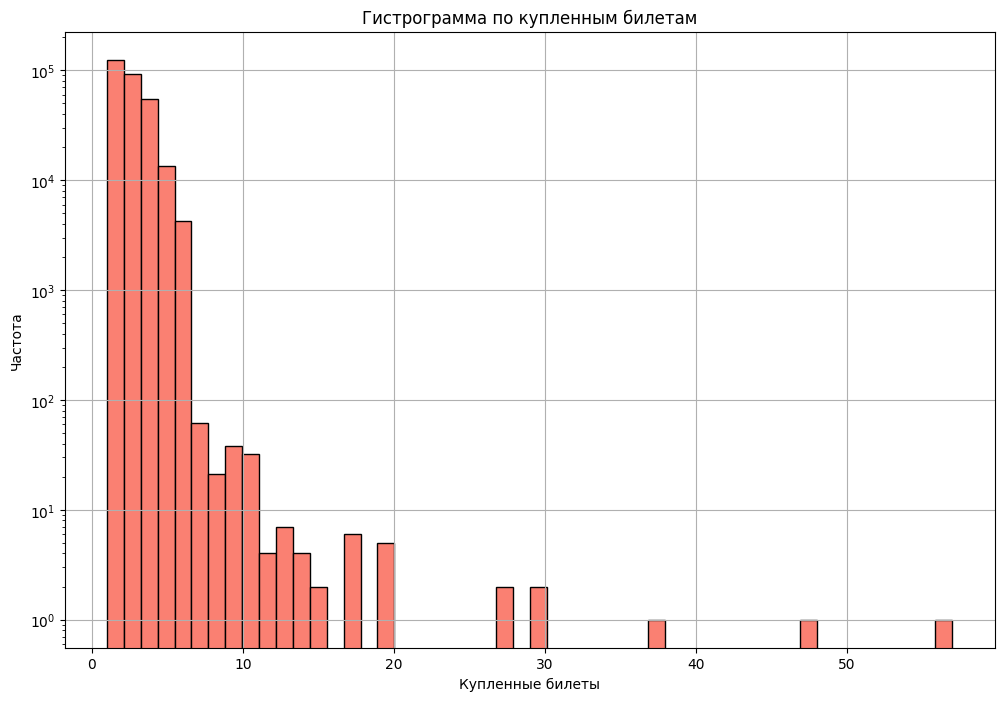

In [33]:
# Построим гистрограмму по 'tickets_count' используя логарифмическую шкалу для нагладности
df_reporter.show_histogram('tickets_count',
                           50,
                           'Гистрограмма по купленным билетам',
                           'Купленные билеты',
                           True)

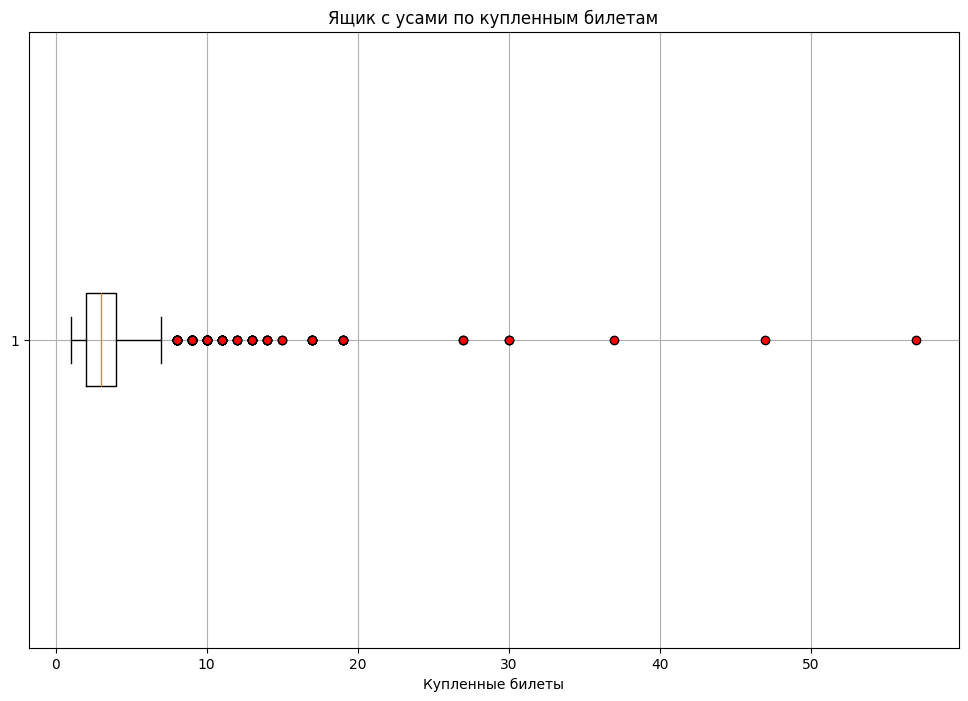

In [34]:
# Построим "ящик с усами" по 'tickets_count'
df_reporter.show_boxplot('tickets_count', 'Ящик с усами по купленным билетам', 'Купленные билеты')

Как видно из приведенных графиков, в подтверждение статистического анализа, по столбцу `revenue_rub` присутствуют выбросы данных.
Отфильтруем датафрейм по 99 перцентилю, посмотрим общую инфорамацию после фильтрации, графики и посчитаем процент оставшихся данных после фильтрации 

<class 'pandas.DataFrame'>
Index: 287162 entries, 0 to 290610
Data columns (total 15 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   user_id                287162 non-null  str           
 1   device_type_canonical  287162 non-null  category      
 2   order_id               287162 non-null  uint32        
 3   order_dt               287162 non-null  object        
 4   order_ts               287162 non-null  datetime64[us]
 5   currency_code          287162 non-null  str           
 6   revenue                287162 non-null  float32       
 7   tickets_count          287162 non-null  uint8         
 8   days_since_prev        265667 non-null  UInt8         
 9   event_id               287162 non-null  uint32        
 10  service_name           287162 non-null  str           
 11  event_type_main        287162 non-null  category      
 12  region_name            287162 non-null  str           
 13  

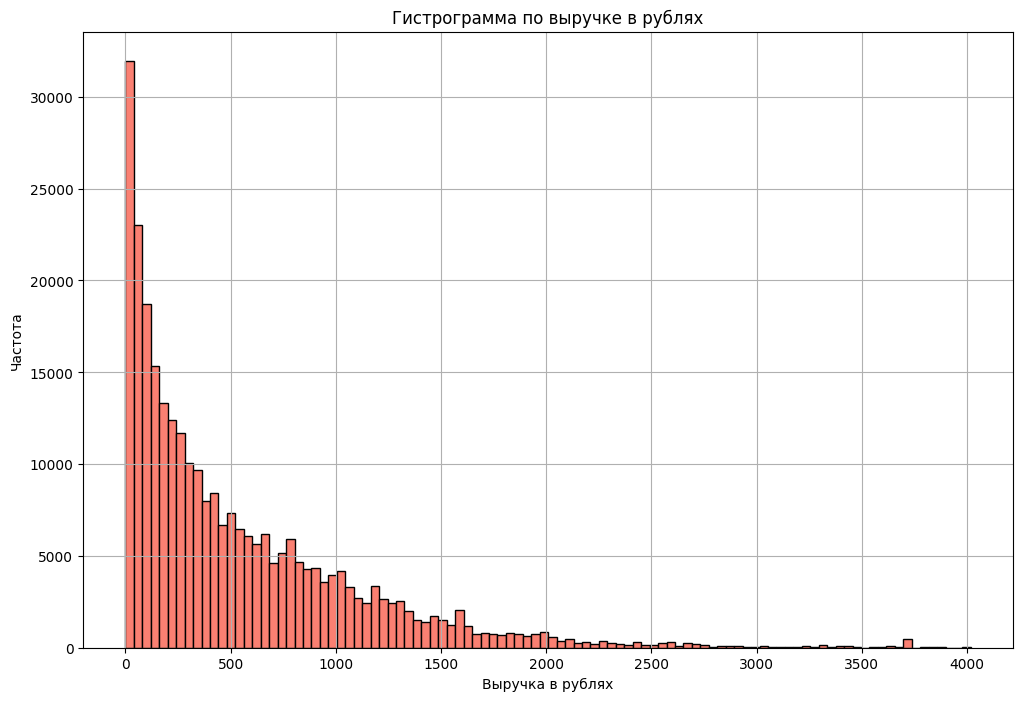

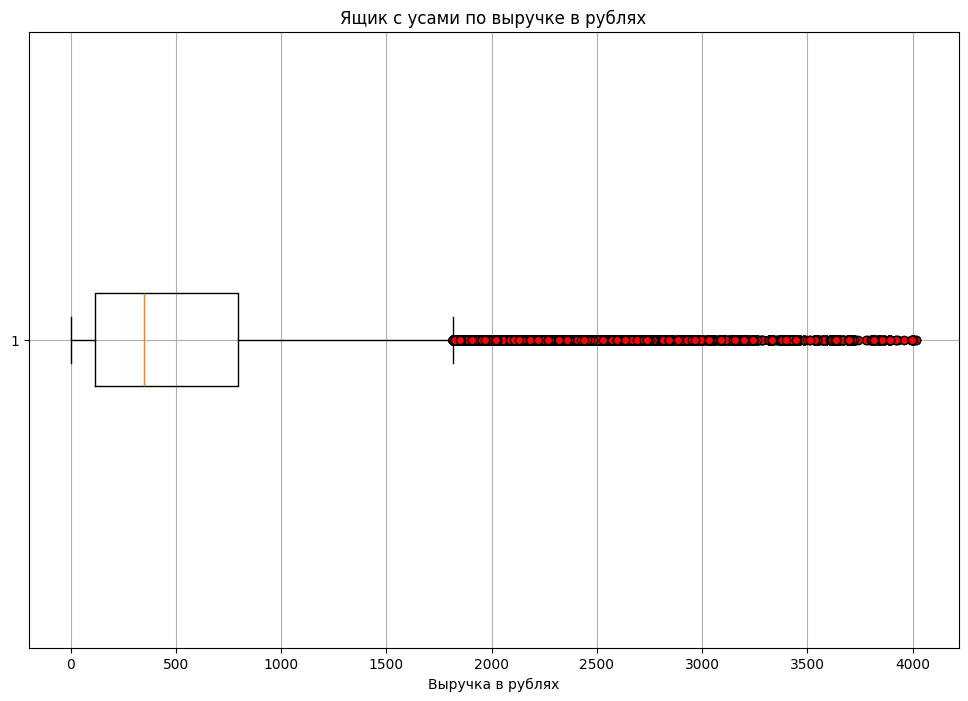

290611 287162 3449 1.19


In [35]:
revenue_rub_99 = df['revenue_rub'].quantile(0.99)
df_revenue_99 = df[df['revenue'] <= revenue_rub_99]

#Перепределим рабочий датафрейм
df = df_revenue_99
df_reporter = DataFrameReporter(df)
df_reporter.show_total_report()
df_reporter.show_histogram('revenue_rub',
                           100,
                           'Гистрограмма по выручке в рублях',
                           'Выручка в рублях')
df_reporter.show_boxplot('revenue_rub', 'Ящик с усами по выручке в рублях', 'Выручка в рублях')

# Проверим сколько осталось строк датафрейма после фильтрации
a, b = len(temp), len(df)
print(a, b, a-b, round((a-b)/a*100, 2))

В результате предобработки данных в итоговый датафрейм было добавлено новое поле "revenue_rub", которое показывает выручку от продажи билетов в рублях. В данном поле были обнаружены отрицательные значения, которые были удалены. Были обнаружены и удалены (оставлена первая запись) неполные дубликаты по полям "user_id" и "order_ts". По тем закакам, которые были оформлены в тенге был сделан пересчет по курсу из специального датасета с курсами тенге на каждую дату из расчета 100 тенге. 
Также был проведен анализ и произведена работа по типизации данных в датафрейме, что позволило уменьшить разрядность по суммовым некоторым полям.
Итоговый датафрейм был отфильтрован по 99 перцентилю по полю "revenue_rub", так как в данном столбце наблюдались значительные выбросы данных. В результате избавления от дубликатов, отрицательных значений и фильтрации по перцентилю итоговый датафрейм был уменьшен на 349 записей, что составило 1,19% от исходного датафрейма.

---
<a id="section3"></a>
### 3. Создание профиля пользователя

В будущем отдел маркетинга планирует создать модель для прогнозирования возврата пользователей. Поэтому сейчас они просят вас построить агрегированные признаки, описывающие поведение и профиль каждого пользователя.

---

**Задача 3.1.** Постройте профиль пользователя — для каждого пользователя найдите:

- дату первого и последнего заказа;
- устройство, с которого был сделан первый заказ;
- регион, в котором был сделан первый заказ;
- билетного партнёра, к которому обращались при первом заказе;
- жанр первого посещённого мероприятия (используйте поле `event_type_main`);
- общее количество заказов;
- средняя выручка с одного заказа в рублях;
- среднее количество билетов в заказе;
- среднее время между заказами.

После этого добавьте два бинарных признака:

- `is_two` — совершил ли пользователь 2 и более заказа;
- `is_five` — совершил ли пользователь 5 и более заказов.

**Рекомендация:** перед тем как строить профиль, отсортируйте данные по времени совершения заказа.

---


In [36]:
# Сортируем датафрейм по времени совершения заказа
df = df.sort_values(["user_id","order_ts"])

In [37]:
# Берём первую запись для каждого пользователя по всем нужным колонкам
first_orders = (df.groupby('user_id')
                .agg({
                    'device_type_canonical': 'first',
                    'region_name': 'first',
                    'service_name': 'first',
                    'event_type_main': 'first'
                })
                .reset_index()
                .rename(columns={
                    'device_type_canonical': 'first_device_type',
                    'region_name': 'first_region',
                    'service_name': 'first_service_name',
                    'event_type_main': 'first_event_type'
                }))
len(first_orders)

21753

In [38]:
# 3. Агрегируем общие показатели по пользователю (как было ранее)
user_aggr_data = (df.groupby('user_id')
                  .agg(
                      first_order_dt=('order_dt', 'min'),
                      last_order_dt=('order_dt', 'max'),
                      qty_orders=('order_id', 'count'),
                      avg_revenue_rub=('revenue_rub', 'mean'),
                      avg_tickets=('tickets_count', 'mean'),
                      avg_order_days=('days_since_prev', 'mean')
                  )
                  .reset_index())

len(user_aggr_data)


21753

In [39]:
#Объединяем данные первого заказа с общими показателями
user_profile = pd.merge(first_orders, user_aggr_data, on='user_id', how='inner')

In [40]:
# Добавляем флаги повторных покупок
user_profile['is_two'] = user_profile['qty_orders'] >= 2
user_profile['is_five'] = user_profile['qty_orders'] >= 5

In [41]:
# Проверяем, что количество записей равно числу уникальных пользователей
print(f"Уникальных пользователей в профиле: {len(user_profile)}")
print(f"Уникальных пользователей в исходных данных: {df['user_id'].nunique()}")
assert len(user_profile) == df['user_id'].nunique(), "Количество записей не совпадает!"

user_profile_reporter = DataFrameReporter(user_profile)
user_profile_reporter.show_total_report()

user_profile.head(10)

Уникальных пользователей в профиле: 21753
Уникальных пользователей в исходных данных: 21753
<class 'pandas.DataFrame'>
RangeIndex: 21753 entries, 0 to 21752
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype   
---  ------              --------------  -----   
 0   user_id             21753 non-null  str     
 1   first_device_type   21753 non-null  category
 2   first_region        21753 non-null  str     
 3   first_service_name  21753 non-null  str     
 4   first_event_type    21753 non-null  category
 5   first_order_dt      21753 non-null  object  
 6   last_order_dt       21753 non-null  object  
 7   qty_orders          21753 non-null  int64   
 8   avg_revenue_rub     21753 non-null  float32 
 9   avg_tickets         21753 non-null  float64 
 10  avg_order_days      13480 non-null  Float64 
 11  is_two              21753 non-null  bool    
 12  is_five             21753 non-null  bool    
dtypes: Float64(1), bool(2), category(2), float32(1), float6

,user_id,first_device_type,first_region,first_service_name,first_event_type,first_order_dt,last_order_dt,qty_orders,avg_revenue_rub,avg_tickets,avg_order_days,is_two,is_five
0,0002849b70a3ce2,mobile,каменевский регион,край билетов,театр,2024-08-20,2024-08-20,1,1521.939941,4.000000,<NA>,False,False
1,0005ca5e93f2cf4,mobile,каменевский регион,мой билет,выставки,2024-07-23,2024-10-06,2,774.010010,3.000000,75.0,True,False
2,000898990054619,mobile,североярская область,лови билет!,другое,2024-07-13,2024-10-23,3,767.213379,2.666667,51.0,True,False
3,00096d1f542ab2b,desktop,каменевский регион,край билетов,театр,2024-08-15,2024-08-15,1,917.830017,4.000000,<NA>,False,False
4,000a55a418c128c,mobile,поленовский край,лучшие билеты,театр,2024-09-29,2024-10-15,2,61.309998,1.500000,16.0,True,False
5,000cf0659a9f40f,mobile,широковская область,лови билет!,концерты,2024-06-20,2024-06-21,13,1175.808472,3.307692,0.083333,True,True
6,00147c9209d45d3,mobile,каменевский регион,облачко,концерты,2024-06-25,2024-06-25,2,352.945007,1.500000,0.0,True,False
7,0018ecd8a38a51b,mobile,медовская область,билеты без проблем,спорт,2024-07-25,2024-07-25,1,0.000000,3.000000,<NA>,False,False
8,00199a573901564,mobile,каменевский регион,билеты без проблем,концерты,2024-06-17,2024-06-17,1,588.119995,4.000000,<NA>,False,False
9,001e7037d013f0f,mobile,златопольский округ,мой билет,другое,2024-07-04,2024-09-29,3,326.623322,1.333333,43.5,True,False


Пропуски тольео в столбце `mean_order_days` - это означает, что данный пользователь совершил только один заказ. Оставим как есть, так как если поставить 0, то это может сильно исказить данные

---

**Задача 3.2.** Прежде чем проводить исследовательский анализ данных и делать выводы, важно понять, с какими данными вы работаете: насколько они репрезентативны и нет ли в них аномалий.

Используя данные о профилях пользователей, рассчитайте:

- общее число пользователей в выборке;
- среднюю выручку с одного заказа;
- долю пользователей, совершивших 2 и более заказа;
- долю пользователей, совершивших 5 и более заказов.

Также изучите статистические показатели:

- по общему числу заказов;
- по среднему числу билетов в заказе;
- по среднему количеству дней между покупками.

По результатам оцените данные: достаточно ли их по объёму, есть ли аномальные значения в данных о количестве заказов и среднем количестве билетов?

Если вы найдёте аномальные значения, опишите их и примите обоснованное решение о том, как с ними поступить:

- Оставить и учитывать их при анализе?
- Отфильтровать данные по какому-то значению, например, по 95-му или 99-му перцентилю?

Если вы проведёте фильтрацию, то вычислите объём отфильтрованных данных и выведите статистические показатели по обновлённому датасету.

In [42]:
# Рассчитаем общее число пользователей в выборке
print(f"Общее количество пользователей: {len(user_profile)}")

Общее количество пользователей: 21753


In [43]:
#Посчитаем среднюю выручку с одного заказа
orders_count = user_profile['qty_orders'].sum()
print(f"Среднняя выручка с одного заказа: {round(user_profile['avg_revenue_rub'].sum()/orders_count, 2)}")

Среднняя выручка с одного заказа: 43.57


In [44]:
# Доля пользователей, совершивших 2 и более заказа
print(f"Доля пользователей, совершивших 2 и более заказа: {round(user_profile['is_two'].sum()/len(user_profile)*100, 2)}")

Доля пользователей, совершивших 2 и более заказа: 61.75


In [45]:
# Доля пользователей, совершивших 5 и более заказа
print(f"Доля пользователей, совершивших 5 и более заказа: {round(user_profile['is_five'].sum()/len(user_profile)*100, 2)}")

Доля пользователей, совершивших 5 и более заказа: 29.07


In [46]:
user_profile_reporter = DataFrameReporter(user_profile)
user_profile.describe()

,qty_orders,avg_revenue_rub,avg_tickets,avg_order_days
count,21753.000000,21753.000000,21753.000000,13480.0
mean,13.201030,575.197693,2.749331,15.980731
std,121.903339,497.310974,0.921695,22.44723
min,1.000000,0.000000,1.000000,0.0
25%,1.000000,220.703323,2.000000,1.0
50%,2.000000,477.262024,2.750000,8.129167
75%,5.000000,782.780029,3.111111,20.666667
max,10179.000000,3891.659912,11.000000,148.0


Проведенный анализ показывает:
* Количество данных 21753 - достаточный объем данных для анализа
* Среднее количество заказов клиента - присутствуют экстремальные выбросы — небольшое число пользователей с аномально высоким числом заказов. При медиане = 2, среднее составляет 13,20, а стандартное отклонение (121,9) сильно превышает среднее. Значение 10 179 заказов при медиане 2 — явная аномалия.
* Среднее количество билетов одного заказа - среднее и медиана практически равны, стандартное отклоение ~ 1 билет, максимальное количество в 11 билетов не стоит рассматривать как выброс - возможно это куплено на группу человек.
* среднее количество дней между заказами - тут стоит учитывать, что это только ~62% данных, так как пропущенные значения это означает что пользователь совершил всего один заказ. 

Вывод: отберем по 99 перцентилю данные по количеству заказов и посмотрим насколько это повлияет на статистику.

In [47]:
qty_orders_99 = user_profile['qty_orders'].quantile(0.99)
user_profile_99 = user_profile[user_profile['qty_orders'] <= qty_orders_99]

# Проверим сколько осталось строк датафрейма после фильтрации
a, b = len(user_profile), len(user_profile_99)
print(a, b, a-b, round((a-b)/a*100, 2))


user_profile_99.describe()

21753 21535 218 1.0


,qty_orders,avg_revenue_rub,avg_tickets,avg_order_days
count,21535.000000,21535.000000,21535.000000,13262.0
mean,6.487068,575.617676,2.749469,16.235815
std,14.236101,499.632172,0.926190,22.541882
min,1.000000,0.000000,1.000000,0.0
25%,1.000000,218.699997,2.000000,1.37963
50%,2.000000,474.260010,2.750000,8.5
75%,5.000000,786.501343,3.133333,21.0
max,151.000000,3891.659912,11.000000,148.0


Фильтрация по 99 перцентилю всё еще показывает выбросы, но уже не такие высокие. Данных стало меньше на 1%.
Попробуем отфильтровать по 95 перцентилю и посмотрим на статистику.

In [48]:
qty_orders_95 = user_profile['qty_orders'].quantile(0.95)
user_profile_95 = user_profile[user_profile['qty_orders'] <= qty_orders_95]

# Проверим сколько осталось строк датафрейма после фильтрации
a, b = len(user_profile), len(user_profile_95)
print(a, b, a-b, round((a-b)/a*100, 2))


user_profile_95.describe()

21753 20694 1059 4.87


,qty_orders,avg_revenue_rub,avg_tickets,avg_order_days
count,20694.000000,20694.000000,20694.000000,12421.0
mean,4.090751,578.182007,2.749717,17.16382
std,5.217882,508.099945,0.942890,22.997652
min,1.000000,0.000000,1.000000,0.0
25%,1.000000,213.542496,2.000000,1.0
50%,2.000000,468.409515,2.750000,9.5
75%,5.000000,799.054626,3.175456,22.333333
max,32.000000,3891.659912,11.000000,148.0


Данных стало меньше примерно на 4,87%, но при этом критические выбросы ушли. 

При 95 перцентиле по количеству заказов данные по количеству билетов и дней между заказами не сильно изменились. Оставим для дальнейшего анализа 95 перцентиль. Создадим итоговый датафрейм для дальнейшего исследовательского анализа данных. 

In [49]:
df_analisys = user_profile_95
#Посмотрим на общую информацию по итоговому датафрейму
df_analisys_reporter = DataFrameReporter(df_analisys)
df_analisys_reporter.show_total_report()
df_analisys_reporter.show_describe()

<class 'pandas.DataFrame'>
Index: 20694 entries, 0 to 21752
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype   
---  ------              --------------  -----   
 0   user_id             20694 non-null  str     
 1   first_device_type   20694 non-null  category
 2   first_region        20694 non-null  str     
 3   first_service_name  20694 non-null  str     
 4   first_event_type    20694 non-null  category
 5   first_order_dt      20694 non-null  object  
 6   last_order_dt       20694 non-null  object  
 7   qty_orders          20694 non-null  int64   
 8   avg_revenue_rub     20694 non-null  float32 
 9   avg_tickets         20694 non-null  float64 
 10  avg_order_days      12421 non-null  Float64 
 11  is_two              20694 non-null  bool    
 12  is_five             20694 non-null  bool    
dtypes: Float64(1), bool(2), category(2), float32(1), float64(1), int64(1), object(2), str(3)
memory usage: 1.6+ MB
Количество столбцов: 13
Количество строк:

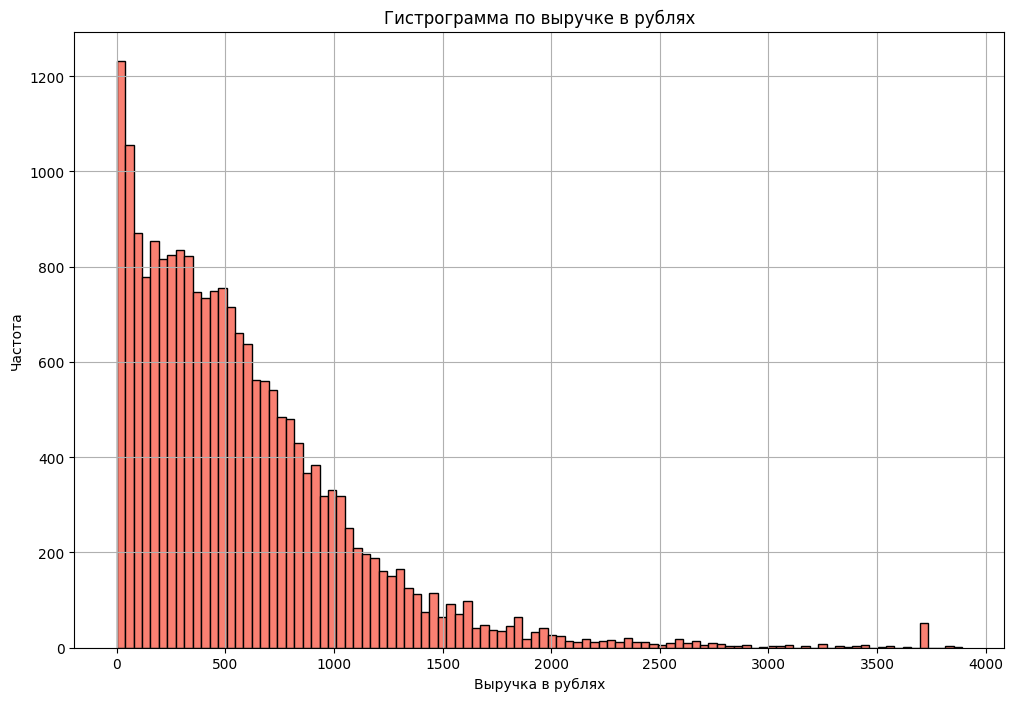

In [50]:
df_analisys_reporter.show_histogram('avg_revenue_rub',
                           100,
                           'Гистрограмма по выручке в рублях',
                           'Выручка в рублях')

По данным графика видно, что данные по сумме выручке положительно ассиметричны (правый хвост). Наибольшее количество заказов делается пользователями в диапахзоне от 100 до 500 рублей. После чего заказов на бОльшую сумму падают. В пике 0 рублей - скорее всего билеты приобретенные по акции/промокоду/бесплатные мероприятия. Так же видно, что есть заказы с выручкой более 3500 рублей, но их крайне мало.
Это говорит о том, что наибольшее количество пользователей совершают траят не очень большую сумму на посещение мероприятий.

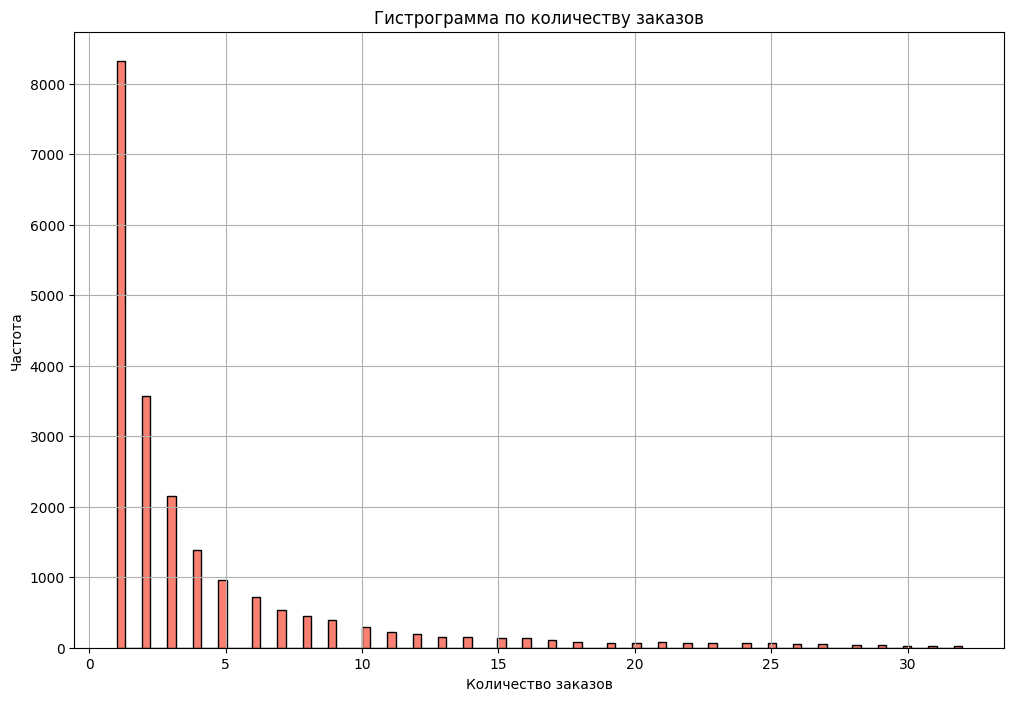

In [51]:
df_analisys_reporter.show_histogram('qty_orders',
                           100,
                           'Гистрограмма по количеству заказов',
                           'Количество заказов')

По данным графика видно, что наибольшее количество заказов совершенное пользователем равно 1.Примерно наполовину меньше делается 2 заказа и на четверть - 3. Встречаются и пользователи, которые сделали более 10 заказов, но их меньшество. 

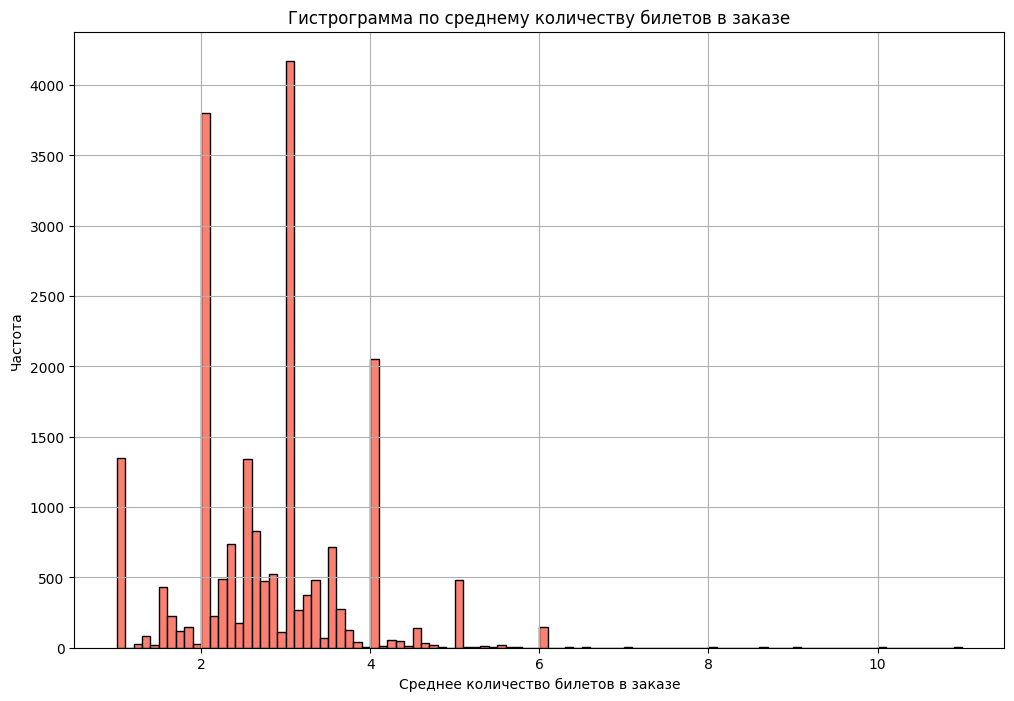

In [52]:
df_analisys_reporter.show_histogram('avg_tickets',
                           100,
                           'Гистрограмма по среднему количеству билетов в заказе',
                           'Среднее количество билетов в заказе')

По данным графика видно, что наибольшее количество пользователей делает заказ на 3 билета, чуть реже на 2. Видно, что заказы в которых 4 билета преобладают над количеством заказов в которых 1 билет. Это говорит о том, что пользователи предпочитают посещать мероприятия небольшой группой, возможно вместе с друзьями и родственниками.

---

### 4. Исследовательский анализ данных

Следующий этап — исследование признаков, влияющих на возврат пользователей, то есть на совершение повторного заказа. Для этого используйте профили пользователей.

<a id="section4"></a>

#### 4.1. Исследование признаков первого заказа и их связи с возвращением на платформу
<a id="section41"></a>
Исследуйте признаки, описывающие первый заказ пользователя, и выясните, влияют ли они на вероятность возвращения пользователя.

---

**Задача 4.1.1.** Изучите распределение пользователей по признакам.

- Сгруппируйте пользователей:
    - по типу их первого мероприятия;
    - по типу устройства, с которого совершена первая покупка;
    - по региону проведения мероприятия из первого заказа;
    - по билетному оператору, продавшему билеты на первый заказ.
- Подсчитайте общее количество пользователей в каждом сегменте и их долю в разрезе каждого признака. Сегмент — это группа пользователей, объединённых определённым признаком, то есть объединённые принадлежностью к категории. Например, все клиенты, сделавшие первый заказ с мобильного телефона, — это сегмент.
- Ответьте на вопрос: равномерно ли распределены пользователи по сегментам или есть выраженные «точки входа» — сегменты с наибольшим числом пользователей?

---


In [53]:
# Разработаем класс UserProfile с различными методами для анализа профиля пользователя
class UserProfile:
    
    def __init__(self, dataframe):
        self.df = dataframe
    
    def create_user_segment(self, group_col, target_col=None, group_agg='count', total_agg='sum',
                            calc_two_plus=False, user_id_col='user_id'):
    #    Создаёт сегмент пользователей.
    #    Параметры:
    #    - group_col: столбец для группировки (категориальный признак)
    #    - target_col: целевой столбец (для исходного режима, обязателен если calc_two_plus=False)
    #    - group_agg: функция агрегации для исходного режима
    #    - total_agg: функция агрегации для вычисления общего значения
    #    - calc_two_plus: если True, вычисляет долю пользователей с is_two == True в каждом сегменте
    #    - user_id_col: столбец с идентификатором пользователя (для режима 2+)
    #    
    #    Возвращает:
    #    - Если calc_two_plus=False: DataFrame с колонками [group_col, target_col, 'ratio']
    #    - Если calc_two_plus=True: DataFrame с колонками [group_col, 'total_users', 'two_plus_users', 'ratio']

        if calc_two_plus:
            # Уникальные пары (пользователь, сегмент) с флагом is_two
            df_unique = self.df[[user_id_col, group_col, 'is_two']].drop_duplicates(
                subset=[user_id_col, group_col])
            
            # Агрегация по сегментам
            result = df_unique.groupby(group_col).agg(
                    total_users=(user_id_col, 'count'),
                two_plus_users=('is_two', 'sum')
            ).reset_index()
            
            result['ratio'] = result['two_plus_users'] / result['total_users'] * 100
            
            return result[[group_col, 'total_users', 'two_plus_users', 'ratio']].sort_values(
                            by=['two_plus_users', 'total_users', 'ratio'], ascending=False)
        else:
            df_segment = self.df.groupby(group_col)[target_col].agg(group_agg).reset_index(name=target_col)
            total = df_segment[target_col].agg(total_agg)
            df_segment['ratio'] = df_segment[target_col] / total * 100
            return df_segment.sort_values('ratio', ascending=False)    
    
    def show_diagramm(self, df_segment, Xcolumn, YColumn, legend=False, title=None,
                      xlabel=None, ylabel=None, width=8, height=6):
        df_segment = df_segment.sort_values(by=Xcolumn)
        plt.figure(figsize=(width, height))
        plt.barh(df_segment[YColumn], df_segment[Xcolumn], color='xkcd:sky blue', edgecolor='black')
        plt.xlabel(xlabel)
        plt.ylabel(ylabel)
        plt.title(title)
        plt.grid()
        plt.show()

In [54]:
# Создадим экземпляр класс UserProfile
user_profile = UserProfile(df_analisys) 

  first_event_type  user_id      ratio
2         концерты     9020  43.587513
1           другое     5217  25.210206
5            театр     4116  19.889823
4          стендап     1076   5.199575
3            спорт      771   3.725718
0         выставки      400   1.932927
6             ёлки       94   0.454238


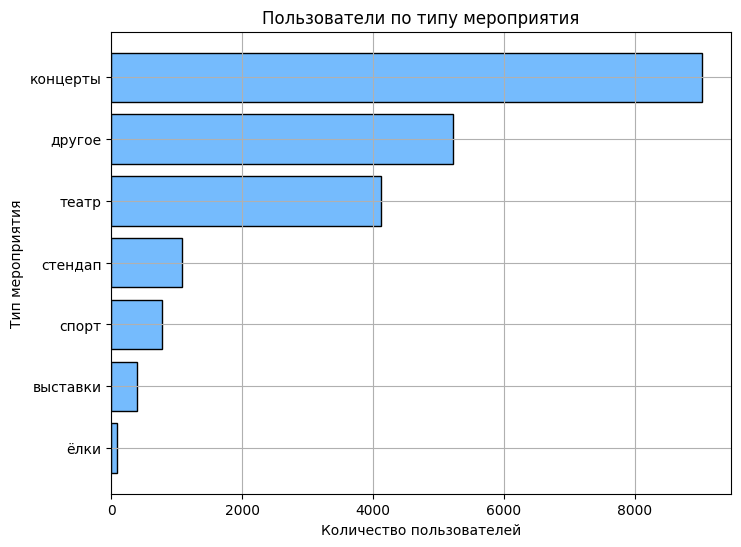

In [55]:
# Сгруппируем пользователей по типу их первого мероприятия
seg_event_type = user_profile.create_user_segment('first_event_type', 'user_id')
print(seg_event_type.head(10))

user_profile.show_diagramm(seg_event_type, title="Пользователи по типу мероприятия",
                            Xcolumn='user_id',
                            YColumn='first_event_type',
                            xlabel="Количество пользователей", 
                            ylabel="Тип мероприятия")


  first_device_type  user_id      ratio
1            mobile    17182  83.028897
0           desktop     3512  16.971103


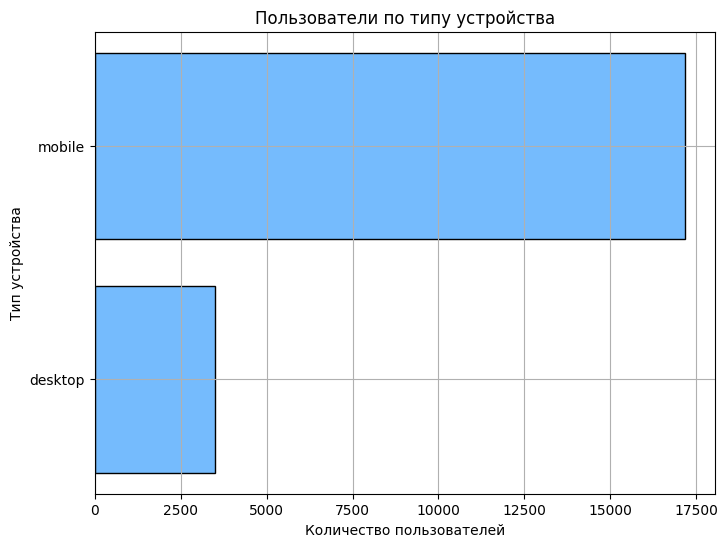

In [56]:
# Сгруппируем пользователей по типу усройства
seg_device_type = user_profile.create_user_segment('first_device_type', 'user_id')
print(seg_device_type.head(10))

user_profile.show_diagramm(seg_device_type, title="Пользователи по типу устройства",
                            Xcolumn='user_id',
                            YColumn='first_device_type',
                            xlabel="Количество пользователей", 
                            ylabel="Тип устройства")

In [57]:
# Сгруппируем пользователей по региону
seg_region = user_profile.create_user_segment('first_region', 'user_id')
print(len(seg_region))


81


            first_region  user_id      ratio
23    каменевский регион     6859  33.144873
60  североярская область     3626  17.521987
77   широковская область     1197   5.784285
45      озернинский край      667   3.223156
41  малиновоярский округ      531   2.565961
74      травяная область      469   2.266357
57  светополянский округ      446   2.155214
52   речиновская область      424   2.048903
78   яблоневская область      401   1.937760
42     медовская область      359   1.734802


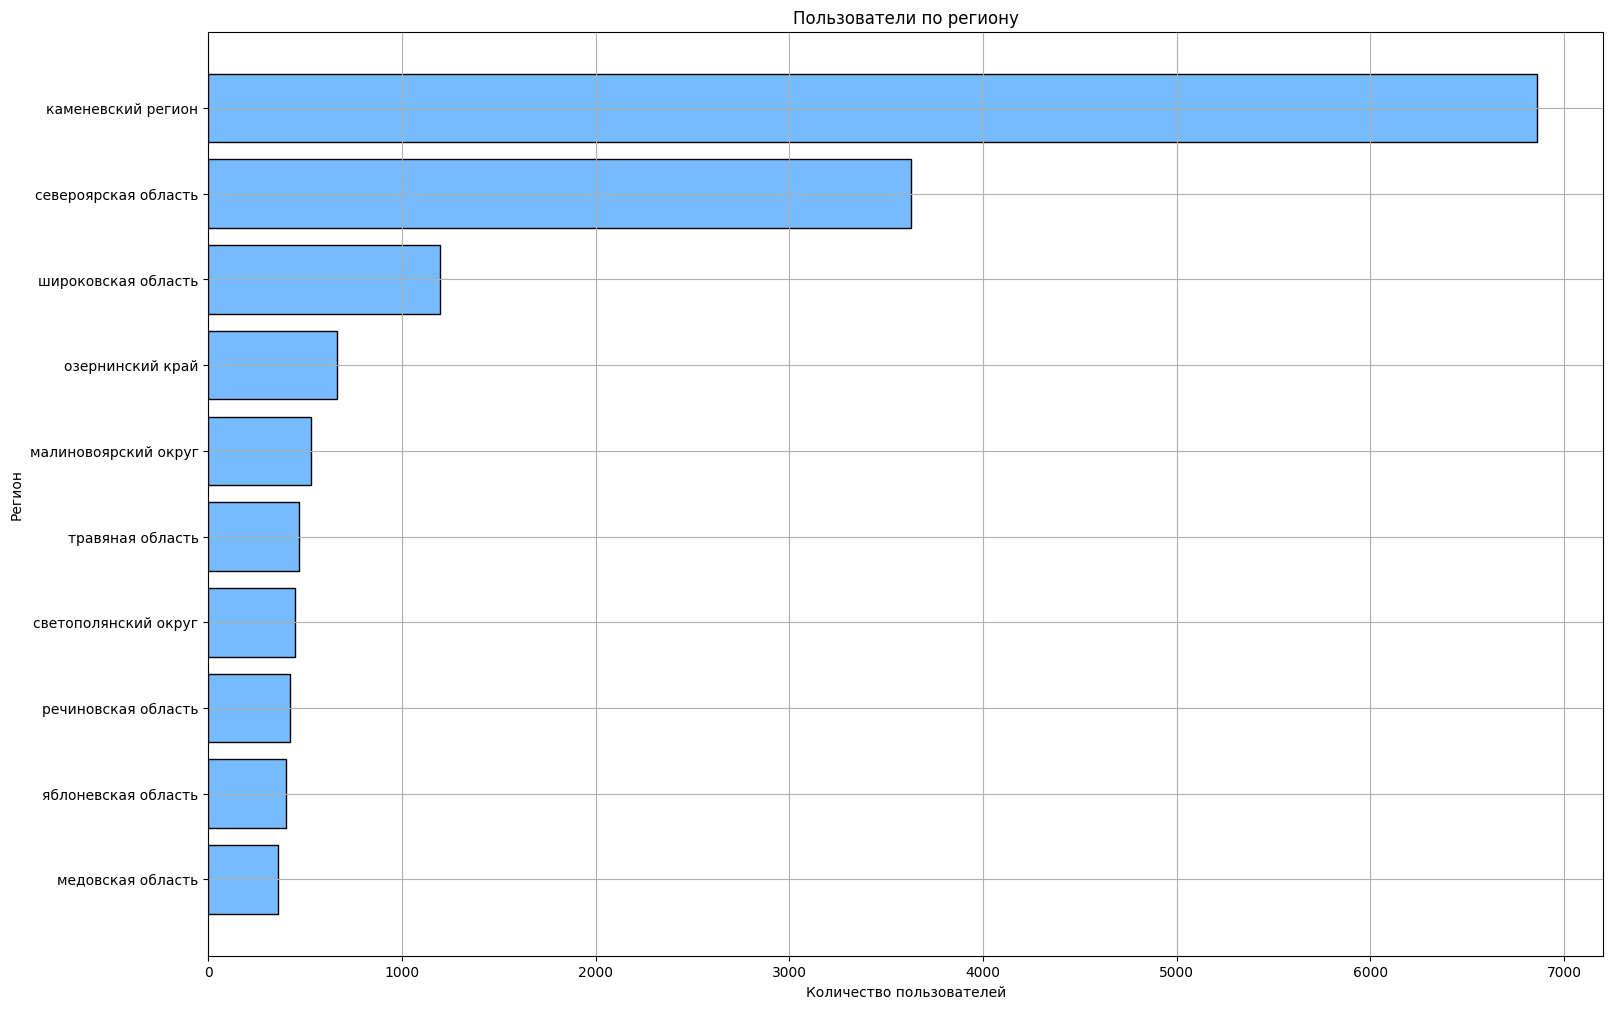

In [58]:
#Отберем в отдельном сегменте регионы у которых доля более 0.5%
seg_top_region = seg_region.head(10)
print(seg_top_region.head(100))
user_profile.show_diagramm(seg_top_region, title="Пользователи по региону",
                            Xcolumn='user_id',
                            YColumn='first_region',
                            xlabel="Количество пользователей", 
                            ylabel="Регион",
                            width=18,
                            height=12)

        first_service_name  user_id      ratio
3       билеты без проблем     4974  24.035952
19             лови билет!     2732  13.201894
22               мой билет     2656  12.834638
4            билеты в руки     2434  11.761863
23                 облачко     2130  10.292839
7           весь в билетах     1252   6.050063
20           лучшие билеты     1137   5.494346
24               прачечная      559   2.701266
17            край билетов      444   2.145549
12            дом культуры      344   1.662318
33                  яблоко      309   1.493186
28             тебе билет!      301   1.454528
11  городской дом культуры      212   1.024452
13             за билетом!      199   0.961631
21                мир касс      198   0.956799
1              show_ticket      162   0.782836
5              быстробилет      161   0.778003
10          выступления.ру       93   0.449406
8                восьмёрка       84   0.405915
6           быстрый кассир       54   0.260945
27           

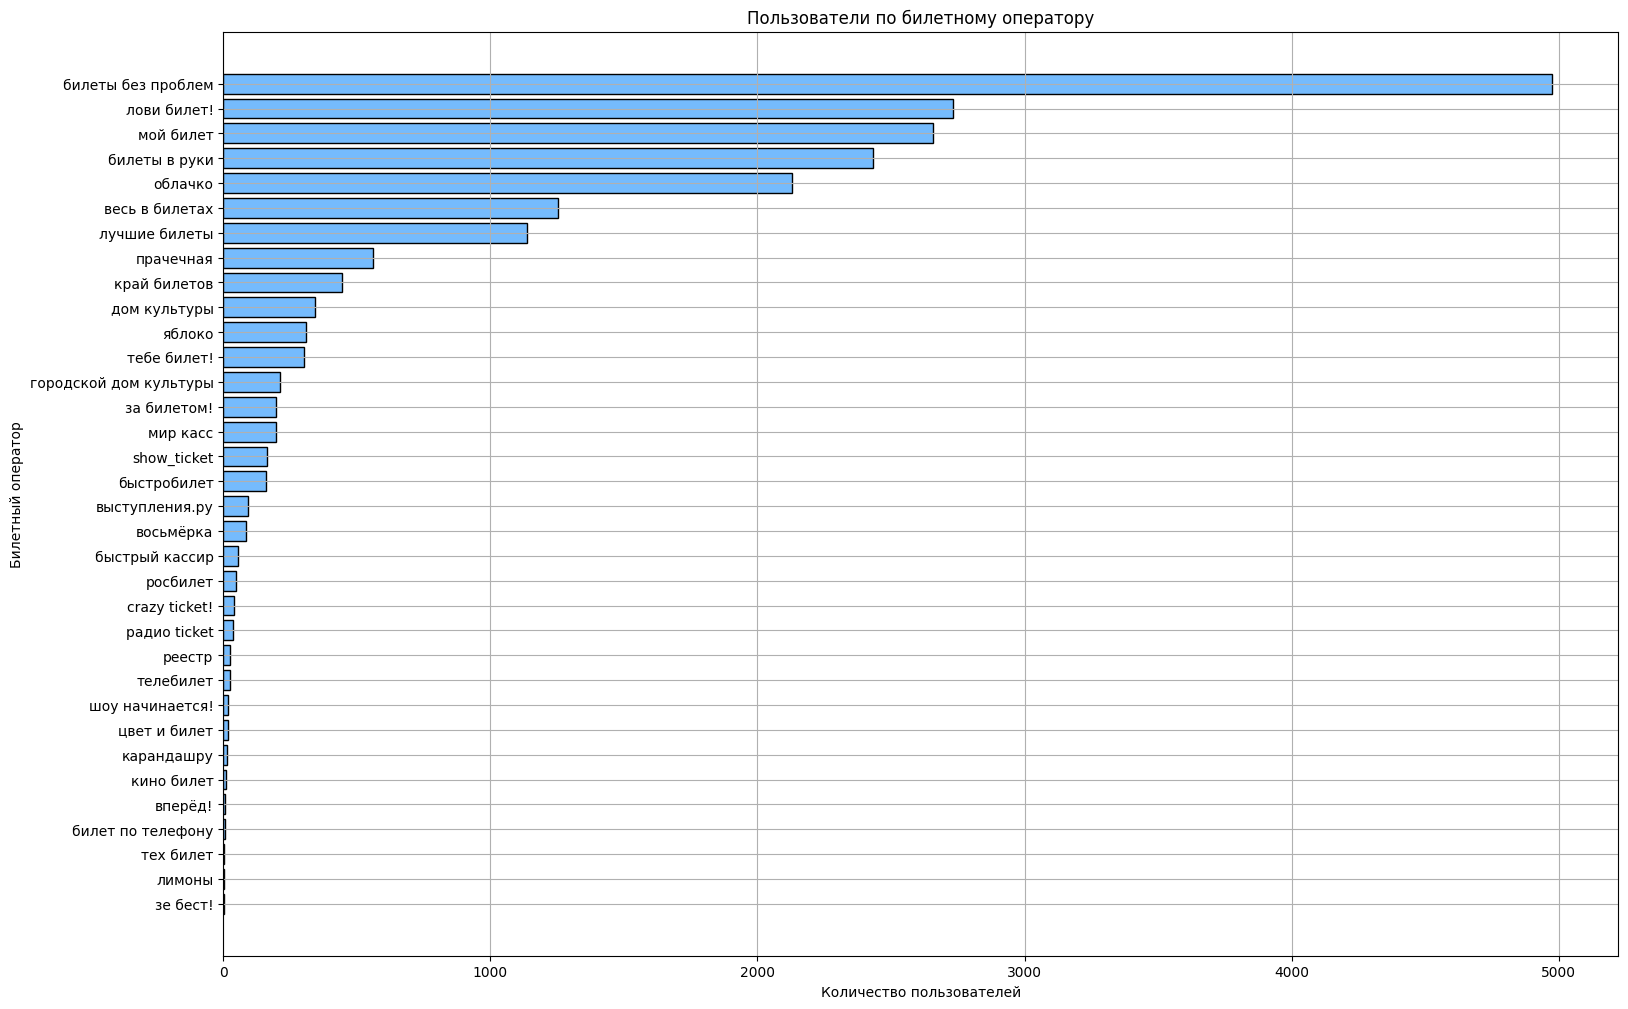

In [59]:
# Сгруппируем пользователей по билетному оператору
seg_service_name = user_profile.create_user_segment('first_service_name', 'user_id')
print(seg_service_name.head(50))

user_profile.show_diagramm(seg_service_name, title="Пользователи по билетному оператору",
                            Xcolumn='user_id',
                            YColumn='first_service_name',
                            xlabel="Количество пользователей", 
                            ylabel="Билетный оператор",
                            width=18,
                            height=12)

Выводы:
* Среди типов мероприятий выделяются концерты (~43%), другое (~26%) и театр (~20%)
* Наибольшая часть пользователей осуществляет заказы с помощью телефона (мобильного прилоложения) - 83%
* среди регионов выделяеься "каменевский регион" - примерно 33% всех пользоватлей, на втором месте "североярская область" ~18%, на третьем месте "широковская область" ~6%. В остальных регионах количество пользоватлей менее 3%
* Среди билетных операторов лидером является "билеты без проблем" - почти четверть всех заказов. Далее примерно одинаково около 12%: "лови билет!", "мой билет", "билеты в руки" и "облачко" 

Таким образом, пользователи распределены неравномерно, существуют выраженные «точки входа»:
- мероприятие - "концерт"
- устройство - "мобильный телефон"
- регион - "каменевский"
- оператор - "билеты без проблем"

---

**Задача 4.1.2.** Проанализируйте возвраты пользователей:

- Для каждого сегмента вычислите долю пользователей, совершивших два и более заказа.
- Визуализируйте результат подходящим графиком. Если сегментов слишком много, то поместите на график только 10 сегментов с наибольшим количеством пользователей. Такое возможно с сегментами по региону и по билетному оператору.
- Ответьте на вопросы:
    - Какие сегменты пользователей чаще возвращаются на Яндекс Афишу?
    - Наблюдаются ли успешные «точки входа» — такие сегменты, в которых пользователи чаще совершают повторный заказ, чем в среднем по выборке?

При интерпретации результатов учитывайте размер сегментов: если в сегменте мало пользователей (например, десятки), то доли могут быть нестабильными и недостоверными, то есть показывать широкую вариацию значений.

---


  first_event_type  total_users  two_plus_users      ratio
2         концерты         9020            5435  60.254989
1           другое         5217            3017  57.830171
5            театр         4116            2557  62.123421
4          стендап         1076             641  59.572491
3            спорт          771             420  54.474708
0         выставки          400             252  63.000000
6             ёлки           94              51  54.255319


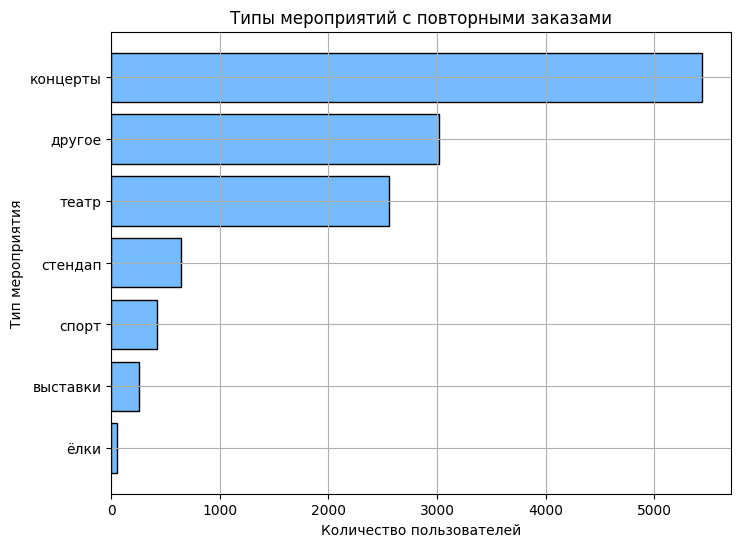

In [60]:
seg_event_type_repeat = user_profile.create_user_segment('first_event_type', target_col=None, calc_two_plus=True)
print(seg_event_type_repeat.head(10))

user_profile.show_diagramm(seg_event_type_repeat, title="Типы мероприятий с повторными заказами",
                            Xcolumn='two_plus_users',
                            YColumn='first_event_type',
                            xlabel="Количество пользователей", 
                            ylabel="Тип мероприятия")

Из проведенного анализа видно, что максимальная доля пользователей, которые совершают повторные заказы у типа мероприятия "выставки" (63%). Однако, стоит отметить, что по данному мероприятию всего 94 пользователя, то есть количество довольно небельшое в общем объеме анализируемых данных. Наибольшее количество пользователей покупают билеты и на концерты (9020 пользователей) и доля повторных заказов составляет ~60%, поэтому этот тип мероприятия более показателен. На втором месте "другое" ~58% повторных заказов и на третьем "театр" ~62%. Стоит отметить, что несмотря на разницу в количестве пользователей по мероприятиям, процент повторных заказов примерно одинаковый вне зависимости от типа мероприятия. Это может говорить о том, что есть группы пользователей, которым нравятся конкретные типы мероприятий и они посещают их повторно.

  first_device_type  total_users  two_plus_users      ratio
1            mobile        17182           10200  59.364451
0           desktop         3512            2173  61.873576


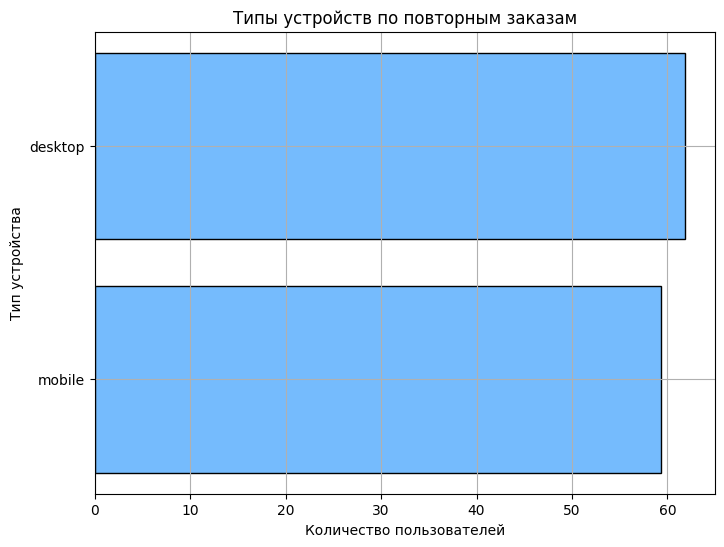

In [61]:
#Повторные заказы по типу усройства
seg_device_type_repeat = user_profile.create_user_segment('first_device_type', target_col=None, calc_two_plus=True)
print(seg_device_type_repeat.head(10))

user_profile.show_diagramm(seg_device_type_repeat, title="Типы устройств по повторным заказам",
                            Xcolumn='ratio',
                            YColumn='first_device_type',
                            xlabel="Количество пользователей", 
                            ylabel="Тип устройства")

Из проведенного анализа видно, что доли совершаемых повтоорных заказов практически одинаковы ~60%. Это может говорить о том, что пользователь единожды заказав билеты просто использует уже апробированный способ заказа и не пытается сделать это с другого типа устройства.

In [62]:
#Повторные заказы по регионам
seg_region_repeat = user_profile.create_user_segment('first_region', target_col=None, calc_two_plus=True)
print(len(seg_region_repeat))

81


                 first_region  total_users  two_plus_users      ratio
23         каменевский регион         6859            4181  60.956408
60       североярская область         3626            2267  62.520684
77        широковская область         1197             761  63.575606
45           озернинский край          667             363  54.422789
41       малиновоярский округ          531             296  55.743879
57       светополянский округ          446             289  64.798206
74           травяная область          469             281  59.914712
52        речиновская область          424             265  62.500000
78        яблоневская область          401             233  58.104738
42          медовская область          359             207  57.660167
39       лугоградская область          348             190  54.597701
76           шанырский регион          322             183  56.832298
69       тепляковская область          312             180  57.692308
61       серебринска

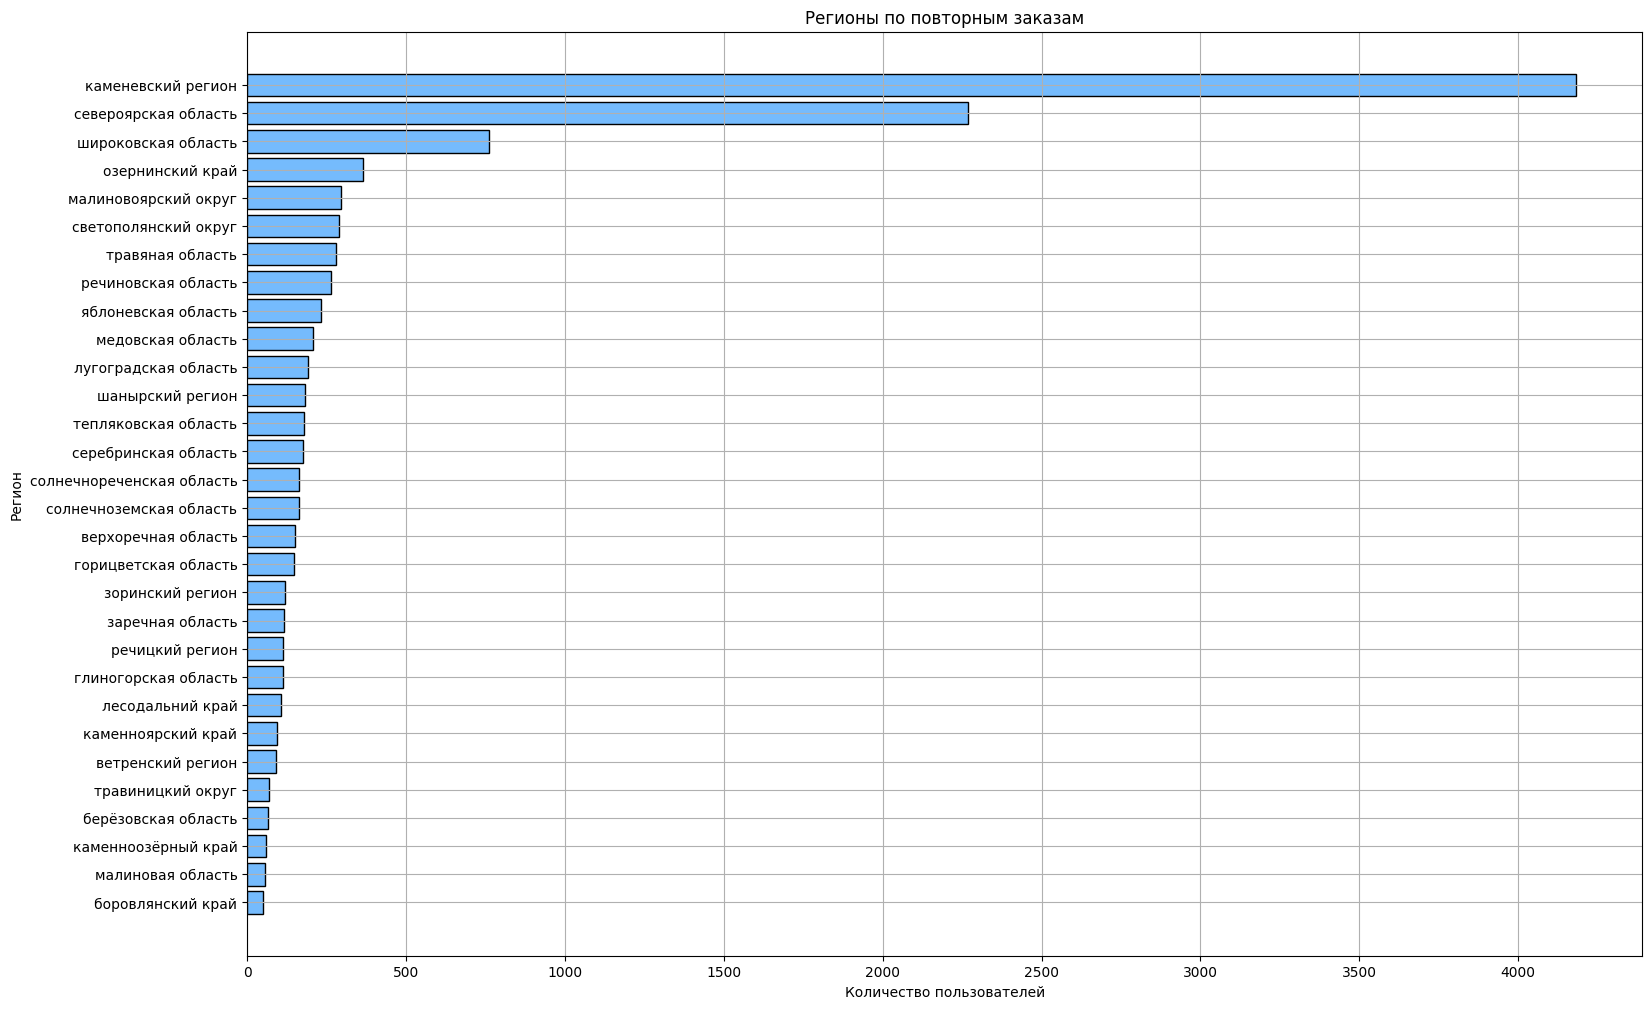

In [63]:
#Ограничимся 10 регионами с наибольшей долей повторных заказов
seg_top_region_repeat = seg_region_repeat.head(30)
print(seg_top_region_repeat.head(30))
user_profile.show_diagramm(seg_top_region_repeat, title="Регионы по повторным заказам",
                            Xcolumn='two_plus_users',
                            YColumn='first_region',
                            xlabel="Количество пользователей", 
                            ylabel="Регион",
                            width=18,
                            height=12)

In [64]:
high_ratio_segments = seg_top_region_repeat[seg_top_region_repeat['ratio'] >= 80]
high_ratio_segments

,first_region,total_users,two_plus_users,ratio


Из проведенного анализа видно, что доля повторных заказов по регионам-лидерам по количеству заказов примерно одинакова и состаляет ~62%. Это говорит о том, что в тех райнах, где пользователи наиболее активны по заказам в первый раз, активно и совершают повторные заказы. Существует доля и в 100% по верхозерскому краю, но такое значение не показательно, так как там всего 1 заказ. 

In [65]:
#Повторные заказы по билетным операторам
seg_service_name_repeat = user_profile.create_user_segment('first_service_name', target_col=None, calc_two_plus=True)

        first_service_name  total_users  two_plus_users       ratio
3       билеты без проблем         4974            2937   59.047045
19             лови билет!         2732            1633   59.773060
22               мой билет         2656            1535   57.793675
4            билеты в руки         2434            1484   60.969597
23                 облачко         2130            1287   60.422535
7           весь в билетах         1252             771   61.581470
20           лучшие билеты         1137             679   59.718558
24               прачечная          559             339   60.644007
17            край билетов          444             285   64.189189
12            дом культуры          344             219   63.662791
28             тебе билет!          301             178   59.136213
33                  яблоко          309             162   52.427184
21                мир касс          198             124   62.626263
11  городской дом культуры          212         

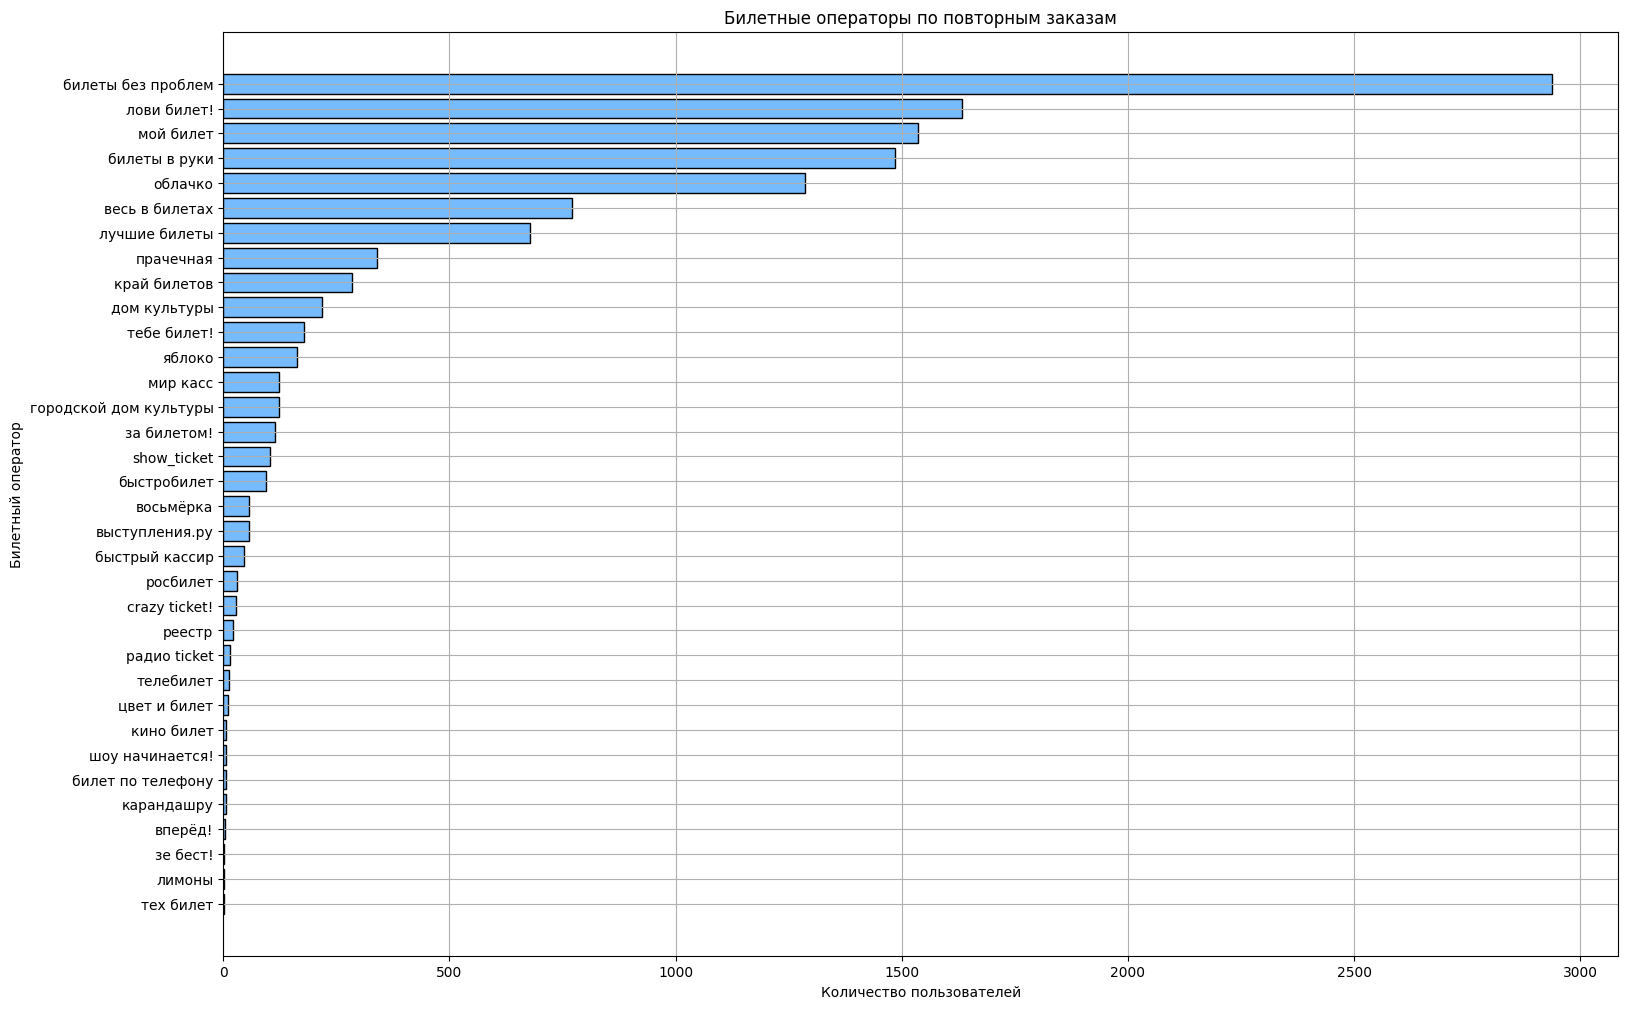

In [66]:
seg_top_service_name_repeat = seg_service_name_repeat.head(len(seg_service_name_repeat))
print(seg_top_service_name_repeat)
user_profile.show_diagramm(seg_top_service_name_repeat, title="Билетные операторы по повторным заказам",
                            Xcolumn='two_plus_users',
                            YColumn='first_service_name',
                            xlabel="Количество пользователей", 
                            ylabel="Билетный оператор",
                            width=18,
                            height=12)

Из проведенного анализа видно, что доли повторных заказов у операторов-лидеров по продаже билетов, также примерно одинакова ~60%

Общий вывод - проведенный анализ, показывает, что доля повторных заказов в каждом сегменте практически одинакова ~60%. При чем как и при первом заказе выбирается то же устройство, тот же тип мероприятия, тот же регион и оператор. Это может говорить о том, что пользователи единожды купив билет не экспериментирут с последующей покупкой. Однако, 60% относительно небольшой показатель, поэтому необходимо искать дополнительную причину совершения пользователями повторных заказов.

---

**Задача 4.1.3.** Опираясь на выводы из задач выше, проверьте продуктовые гипотезы:

- **Гипотеза 1.** Тип мероприятия влияет на вероятность возврата на Яндекс Афишу: пользователи, которые совершили первый заказ на спортивные мероприятия, совершают повторный заказ чаще, чем пользователи, оформившие свой первый заказ на концерты.
- **Гипотеза 2.** В регионах, где больше всего пользователей посещают мероприятия, выше доля повторных заказов, чем в менее активных регионах.

---

In [67]:
# Проверка гипотезы 1
#seg_event_type - сегмент по типам мероприятий
#seg_event_type_repeat - сегмент по повторным заказам по типам мероприятий

# Объединяем сегменты по типу события
merged_event_type = pd.merge(seg_event_type[['first_event_type', 'user_id']],
                  seg_event_type_repeat[['first_event_type', 'two_plus_users']],
                  on='first_event_type')

# Вычисляем долю
merged_event_type['share'] = (merged_event_type['two_plus_users'] / merged_event_type['user_id']) * 100

# Выводим для нужных типов
for event in ['спорт', 'концерты']:
    share = merged_event_type.loc[merged_event_type['first_event_type'] == event, 'share'].values[0]
    print(f"{event}: {share:.2f}%")

спорт: 54.47%
концерты: 60.25%


Вывод: гипотеза № 1 не подтверждается, пользователи, которые сделали перввый раз заказ на концерты чаще делают второй заказ, в отличие от пользователей, которые сделали первый заказ на спортивное мероприятие.

In [68]:
# Проверка гипотезы 2
#seg_top_region - сегмент топ 10 регионов по количеству заказов
#seg_top_region_repeat - сегмент топ 10 по повторным заказам по регионам

# Объединяем сегменты по типу события
merged_region = pd.merge(seg_top_region[['first_region', 'user_id']],
                  seg_top_region_repeat[['first_region', 'two_plus_users']],
                  on='first_region')

# Вычисляем долю
merged_region['share'] = (merged_region['two_plus_users'] / merged_region['user_id']) * 100
merged_region.head(10).sort_values('share', ascending=False)


,first_region,user_id,two_plus_users,share
6,светополянский округ,446,289,64.798206
2,широковская область,1197,761,63.575606
1,североярская область,3626,2267,62.520684
7,речиновская область,424,265,62.500000
0,каменевский регион,6859,4181,60.956408
5,травяная область,469,281,59.914712
8,яблоневская область,401,233,58.104738
9,медовская область,359,207,57.660167
4,малиновоярский округ,531,296,55.743879
3,озернинский край,667,363,54.422789


Вывод: гипотеза № 2 не подтверждается. Наибольшее количество заказов в каменевском районе, однако доля повторных заказов ~61%, в то время как светополянский округ лидирует по доле повторных заказов (~65%) при 443 заказах (7 место в топ регионов) 

---
<a id="section42"></a>
#### 4.2. Исследование поведения пользователей через показатели выручки и состава заказа

Изучите количественные характеристики заказов пользователей, чтобы узнать среднюю выручку сервиса с заказа и количество билетов, которое пользователи обычно покупают.

Эти метрики важны не только для оценки выручки, но и для оценки вовлечённости пользователей. Возможно, пользователи с более крупными и дорогими заказами более заинтересованы в сервисе и поэтому чаще возвращаются.

---

**Задача 4.2.1.** Проследите связь между средней выручкой сервиса с заказа и повторными заказами.

- Постройте сравнительные гистограммы распределения средней выручки с билета (`avg_revenue_rub`):
    - для пользователей, совершивших один заказ;
    - для вернувшихся пользователей, совершивших 2 и более заказа.
- Ответьте на вопросы:
    - В каких диапазонах средней выручки концентрируются пользователи из каждой группы?
    - Есть ли различия между группами?

Текст на сером фоне:
    
**Рекомендация:**

1. Используйте одинаковые интервалы (`bins`) и прозрачность (`alpha`), чтобы визуально сопоставить распределения.
2. Задайте параметру `density` значение `True`, чтобы сравнивать форму распределений, даже если число пользователей в группах отличается.

---


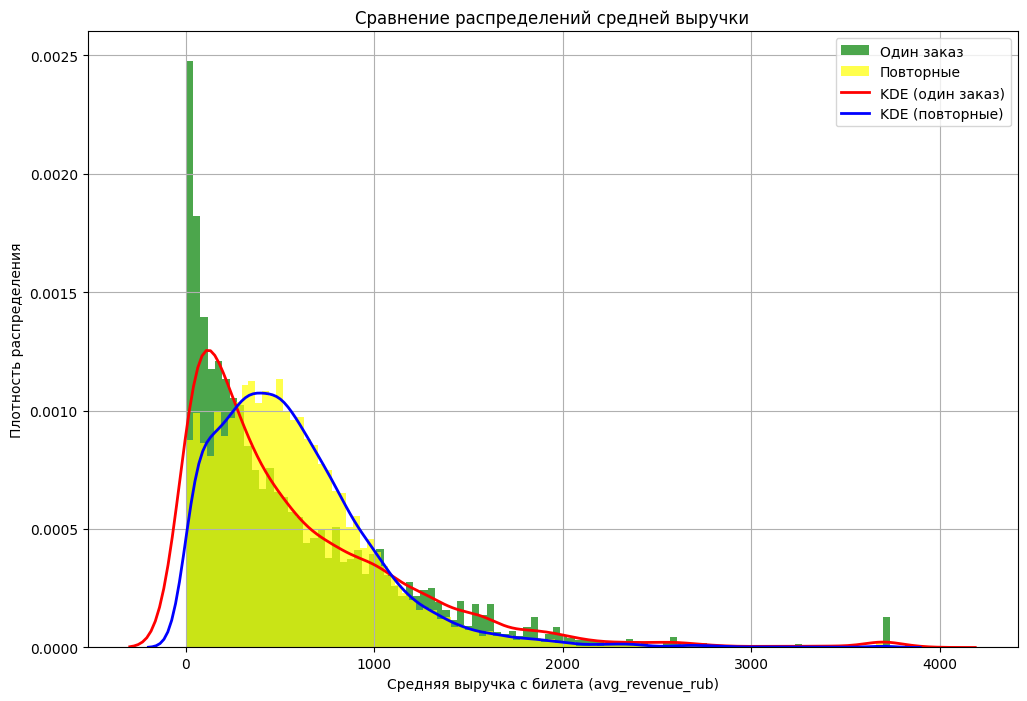

In [69]:
#Выделилим отдельно датафреймы с одним заказом и более однго
one_order = df_analisys[df_analisys['qty_orders'] == 1].copy()
multiple_orders = df_analisys[df_analisys['qty_orders'] >= 2].copy()

# Построение гистограмм
plt.figure(figsize=(12, 8))
plt.hist(one_order['avg_revenue_rub'], bins=100, alpha=0.7, density=True,
         label='Один заказ', color='green')
plt.hist(multiple_orders['avg_revenue_rub'], bins=100, alpha=0.7, density=True,
         label='Повторные', color='yellow')

# Добавляем KDE (сглаженные кривые плотности)
sns.kdeplot(one_order['avg_revenue_rub'], color='red', linewidth=2, label='KDE (один заказ)')
sns.kdeplot(multiple_orders['avg_revenue_rub'], color='blue', linewidth=2, label='KDE (повторные)')

plt.xlabel('Средняя выручка с билета (avg_revenue_rub)')
plt.ylabel('Плотность распределения')
plt.title('Сравнение распределений средней выручки')
plt.legend()
plt.grid(True)
plt.show()

Выводы:
* Пользователи с одним заказом в основном концентрируются от 100 до 500 рублей средней выручки
* Пользователи с двумя и более заказов - от 100 до 1000
* Пользователи с повторными заказами принсосят больше выручки, то есть пользователи тратят больше, чем при первом заказе

---

**Задача 4.2.2.** Сравните распределение по средней выручке с заказа в двух группах пользователей:

- совершившие 2–4 заказа;
- совершившие 5 и более заказов.

Ответьте на вопрос: есть ли различия по значению средней выручки с заказа между пользователями этих двух групп?

---


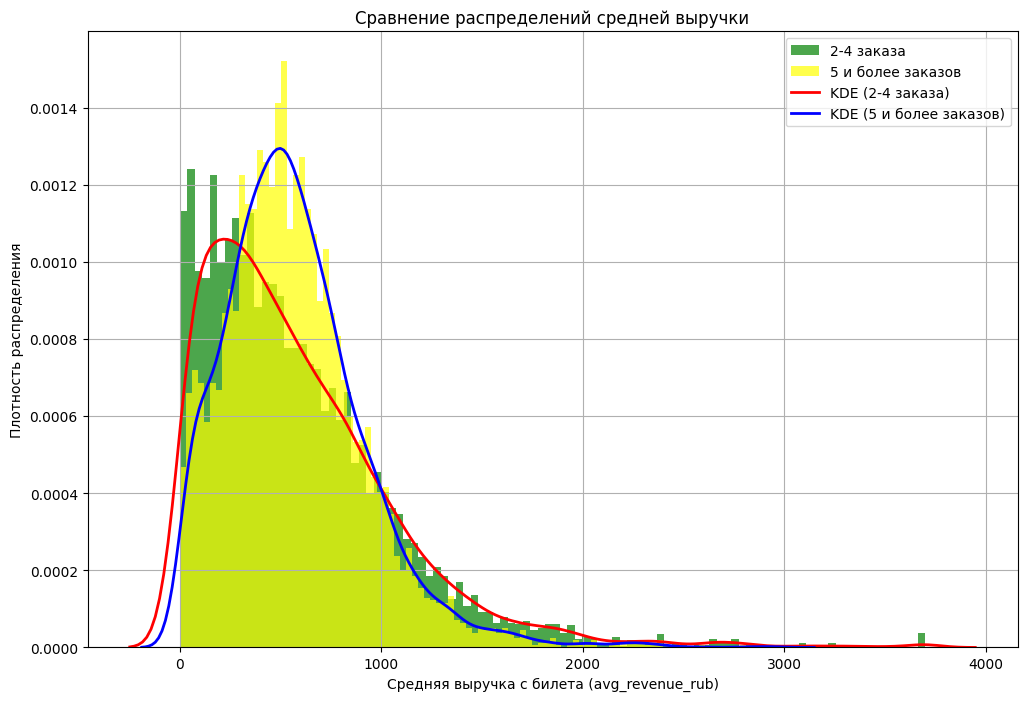

In [70]:
#Выделилим отдельно датафреймы с 2-4 закза и более однго
two_four_order = df_analisys[(df_analisys['qty_orders'] >= 2) & (df_analisys['qty_orders'] <= 4)].copy()
five_orders = df_analisys[df_analisys['is_five'] == True].copy()

# Построение гистограмм
plt.figure(figsize=(12, 8))
plt.hist(two_four_order['avg_revenue_rub'], bins=100, alpha=0.7, density=True,
         label='2-4 заказа', color='green')
plt.hist(five_orders['avg_revenue_rub'], bins=100, alpha=0.7, density=True,
         label='5 и более заказов', color='yellow')

# Добавляем KDE (сглаженные кривые плотности)
sns.kdeplot(two_four_order['avg_revenue_rub'], color='red', linewidth=2, label='KDE (2-4 заказа)')
sns.kdeplot(five_orders['avg_revenue_rub'], color='blue', linewidth=2, label='KDE (5 и более заказов)')

plt.xlabel('Средняя выручка с билета (avg_revenue_rub)')
plt.ylabel('Плотность распределения')
plt.title('Сравнение распределений средней выручки')
plt.legend()
plt.grid(True)
plt.show()

Вывод: пользователи, совершившие 5 и более заказов приносят выручки больше. Пик приходится на 500 рублей средней выручки с билета. Пользователи от 2-4 заказов принсят меньше средней выручки, пик приходится примерно на 200 рублей выручки с билета.

---

**Задача 4.2.3.** Проанализируйте влияние среднего количества билетов в заказе на вероятность повторной покупки.

- Изучите распределение пользователей по среднему количеству билетов в заказе (`avg_tickets_count`) и опишите основные наблюдения.
- Разделите пользователей на несколько сегментов по среднему количеству билетов в заказе:
    - от 1 до 2 билетов;
    - от 2 до 3 билетов;
    - от 3 до 5 билетов;
    - от 5 и более билетов.
- Для каждого сегмента подсчитайте общее число пользователей и долю пользователей, совершивших повторные заказы.
- Ответьте на вопросы:
    - Как распределены пользователи по сегментам — равномерно или сконцентрировано?
    - Есть ли сегменты с аномально высокой или низкой долей повторных покупок?

---

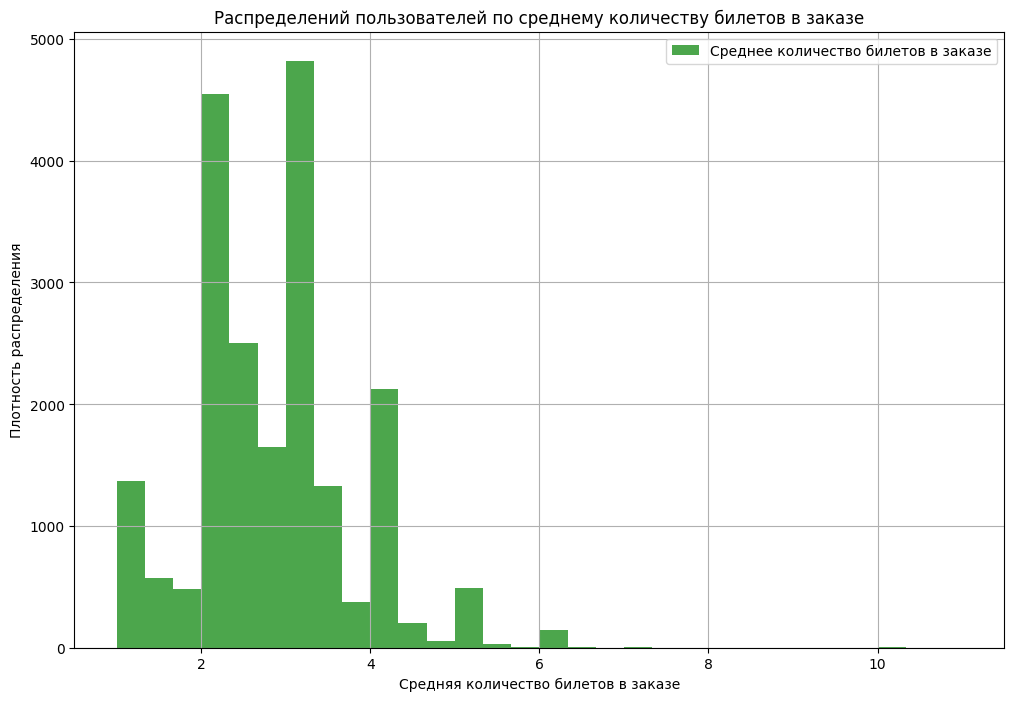

In [71]:
#Выделилим отдельно датафрейм для анализа билетов
tickets = df_analisys[df_analisys['avg_tickets'].notna()].copy()

# Построение гистограммы
plt.figure(figsize=(12, 8))
plt.hist(tickets['avg_tickets'], bins=30, alpha=0.7, label='Среднее количество билетов в заказе', color='green')
plt.xlabel('Средняя количество билетов в заказе')
plt.ylabel('Плотность распределения')
plt.title('Распределений пользователей по среднему количеству билетов в заказе')
plt.legend()
plt.grid(True)
plt.show()

Вывод: Распределений пользователей по среднему количеству билетов в заказе показывает, что наиболее часто пользователи заказывают 3 билета, чуть реже - 2. Так же стоит отметить, что нередко заказывают 4 билета или 1. Это говорит о том, что пользователи видимо предпочитают ходить на мероприятие группой, чаще втроем или вдвоем.

In [72]:
tickets_analisys = df_analisys.copy()

# Функция, которая по числу билетов возвращает имя группы
def get_group(x):
    if x < 2:
        return '1-2 билета'
    elif x < 3:
        return '2-3 билета'
    elif x < 5:
        return '3-5 билетов'
    else:
        return '5+ билетов'

tickets_analisys['group'] = tickets_analisys['avg_tickets'].apply(get_group)

result = tickets_analisys.groupby('group').agg(
    всего_пользователей=('user_id', 'count'),
    повторные=('is_two', 'sum')
)
result['доля_повторных_%'] = (result['повторные'] / result['всего_пользователей'] * 100).round(1)

print(result)


             всего_пользователей  повторные  доля_повторных_%
group                                                        
1-2 билета                  2415       1235              51.1
2-3 билета                  8699       6187              71.1
3-5 билетов                 8896       4818              54.2
5+ билетов                   684        133              19.4


Вывод:
* Пользователи распределены по сегментам сконцентрировано.Больше всего людей в двух группах: 2–3 билета (8657 человек) и 3–5 билетов (8833 человека). Вместе они составляют почти 85% всех пользователей. Группа 1–2 билета заметно меньше (2435), а группа 5+ билетов совсем маленькая (660).То есть основная масса людей покупает в среднем от 2 до 5 билетов за заказ. Равномерного распределения нет.
* Аномально высокая доля — в группе 2–3 билета (71.4%). Почти три из четырёх таких пользователей возвращаются за новыми покупками.
Аномально низкая доля — в группе 5+ билетов (всего 18.8%). Те, кто покупает много билетов за раз почти не возвращаются.
Группа 3–5 билетов (53.8%) и 1–2 билета (50.7%) — примерно половина покупает ещё раз.

---
<a id="section43"></a>
#### 4.3. Исследование временных характеристик первого заказа и их влияния на повторные покупки

Изучите временные параметры, связанные с первым заказом пользователей:

- день недели первой покупки;
- время с момента первой покупки — лайфтайм;
- средний интервал между покупками пользователей с повторными заказами.

---

**Задача 4.3.1.** Проанализируйте, как день недели, в которой была совершена первая покупка, влияет на поведение пользователей.

- По данным даты первого заказа выделите день недели.
- Для каждого дня недели подсчитайте общее число пользователей и долю пользователей, совершивших повторные заказы. Результаты визуализируйте.
- Ответьте на вопрос: влияет ли день недели, в которую совершена первая покупка, на вероятность возврата клиента?

---


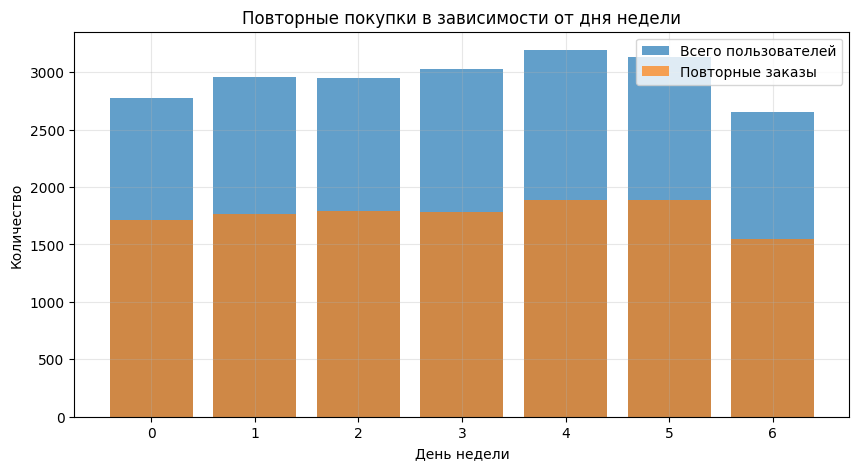

   weekday_num  total_users  repeats  repeat_rate
0            0         2779     1715    61.712846
1            1         2958     1767    59.736308
2            2         2949     1790    60.698542
3            3         3028     1780    58.784676
4            4         3193     1883    58.972753
5            5         3131     1889    60.332162
6            6         2656     1549    58.320783


In [73]:
days_analisys = df_analisys.copy()
days_analisys['first_order_dt'] = pd.to_datetime(days_analisys['first_order_dt'])

# Получаем номер дня недели (0 = понедельник, 6 = воскресенье)
days_analisys['weekday_num'] = days_analisys['first_order_dt'].dt.dayofweek

days_stats = days_analisys.groupby('weekday_num').agg(
    total_users=('user_id', 'count'),
    repeats=('is_two', 'sum')   
).reset_index()

days_stats['repeat_rate'] = days_stats['repeats'] / days_stats['total_users']*100
plt.figure(figsize=(10, 5))
plt.bar(days_stats['weekday_num'], days_stats['total_users'], label='Всего пользователей', alpha=0.7)
plt.bar(days_stats['weekday_num'], days_stats['repeats'], label='Повторные заказы', alpha=0.7)
plt.xlabel('День недели')
plt.ylabel('Количество')
plt.title('Повторные покупки в зависимости от дня недели')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 8. Печатаем табличку
print(days_stats)

Выводы:
Максимальная доля возврата – в понедельник (61,33%)
Минимальная доля – в воскресенье (58,13%)
Разница – около 3,2 процентных пункта
При таком большом количестве наблюдений (от 2600 до 3200 пользователей в день) разница в 3% является значимой. Это означает, что наблюдаемые различия не случайны.

Клиенты, которые совершили первую покупку в понедельник, возвращаются немного чаще.
Клиенты с первой покупкой в воскресенье возвращаются реже.
Однако в целом разница небольшая – день недели не является главным фактором возврата, но влияет на него.

---

**Задача 4.3.2.** Изучите, как средний интервал между заказами влияет на удержание клиентов.

- Рассчитайте среднее время между заказами для двух групп пользователей:
    - совершившие 2–4 заказа;
    - совершившие 5 и более заказов.
- Исследуйте, как средний интервал между заказами влияет на вероятность повторного заказа, и сделайте выводы.

---


In [74]:
order_days_analisys = df_analisys.copy()

# Средний интервал для группы 2-4 заказа (is_two True, is_five False)
order_days_analisys_two = order_days_analisys[(order_days_analisys['is_two'] == True) & (order_days_analisys['is_five'] == False)]['avg_order_days'].mean()

# Средний интервал для группы 5+ заказов (is_five True)
order_days_analisys_five = order_days_analisys[order_days_analisys['is_five'] == True]['avg_order_days'].mean()

print("2-4 заказа:", order_days_analisys_two)
print("5 и более заказов:", order_days_analisys_five)

2-4 заказа: 21.45445913630609
5 и более заказов: 11.139447937949026


Выводы:
* Пользователи, которые дошли до 5+ заказов, заказывают в 2 раза чаще (11 дней против 21 дня).

---
<a id="section44"></a>
#### 4.4. Корреляционный анализ количества покупок и признаков пользователя

Изучите, какие характеристики первого заказа и профиля пользователя могут быть связаны с числом покупок. Для этого используйте универсальный коэффициент корреляции `phi_k`, который позволяет анализировать как числовые, так и категориальные признаки.

---

**Задача 4.4.1:** Проведите корреляционный анализ:
- Рассчитайте коэффициент корреляции `phi_k` между признаками профиля пользователя и числом заказов (`total_orders`). При необходимости используйте параметр `interval_cols` для определения интервальных данных.
- Проанализируйте полученные результаты. Если полученные значения будут близки к нулю, проверьте разброс данных в `total_orders`. Такое возможно, когда в данных преобладает одно значение: в таком случае корреляционный анализ может показать отсутствие связей. Чтобы этого избежать, выделите сегменты пользователей по полю `total_orders`, а затем повторите корреляционный анализ. Выделите такие сегменты:
    - 1 заказ;
    - от 2 до 4 заказов;
    - от 5 и выше.
- Визуализируйте результат корреляции с помощью тепловой карты.
- Ответьте на вопрос: какие признаки наиболее связаны с количеством заказов?

---

In [75]:
#Ранее профиль пользователя строили по параметрам: тип устройства, тип мероприятия, регион и билетный оператор. Будем искать корреляцию по количеству заказов среди именно этих параметров.
cols = ['qty_orders', 'first_device_type', 'first_region', 'first_service_name', 'first_event_type']

corr_subset = df_analisys[cols].copy()
phi_matrix_all = corr_subset.phik_matrix(interval_cols=['qty_orders'])

# Извлекаем корреляции с qty_orders (исключаем саму строку qty_orders)
corr_with_orders_all = phi_matrix_all.loc[phi_matrix_all.index != 'qty_orders', 'qty_orders'].sort_values(ascending=False)
print("Корреляция phi_k между признаками профиля и qty_orders (все данные)")
print(corr_with_orders_all)



Корреляция phi_k между признаками профиля и qty_orders (все данные)
first_service_name    0.043229
first_event_type      0.032164
first_device_type     0.026565
first_region          0.000000
Name: qty_orders, dtype: float64


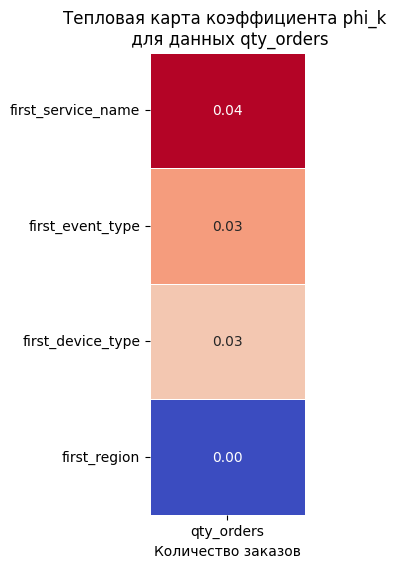

In [76]:
plt.figure(figsize=(2, 6))

# Берём столбец 'qty_orders', удаляем из него строку 'qty_orders' и сортируем
data_heatmap = phi_matrix_all['qty_orders'].drop('qty_orders').sort_values(ascending=False)

# Преобразуем Series в DataFrame (формат (n,1)) для sns.heatmap
sns.heatmap(data_heatmap.to_frame(),
            annot=True,
            fmt='.2f',
            cmap='coolwarm',
            linewidths=0.5,
            cbar=False)

plt.title('Тепловая карта коэффициента phi_k \n для данных qty_orders')
plt.xlabel('Количество заказов')
plt.show()

In [77]:
#Распределение количества заказов
print(corr_subset['qty_orders'].value_counts().sort_index())

qty_orders
1     8321
2     3572
3     2152
4     1385
5      959
6      724
7      532
8      448
9      389
10     294
11     227
12     200
13     149
14     145
15     133
16     132
17     110
18      87
19      69
20      68
21      78
22      60
23      61
24      66
25      64
26      54
27      48
28      40
29      41
30      24
31      31
32      31
Name: count, dtype: int64


In [78]:
def segment_orders(x):
    if x == 1:
        return '1 заказ'
    elif 2 <= x <= 4:
        return '2-4 заказа'
    else:  # x >= 5
        return '5+ заказов'

corr_subset['segment'] = corr_subset['qty_orders'].apply(segment_orders)

# Проверим размеры сегментов
print("Размеры сегментов:")
print(corr_subset['segment'].value_counts())

Размеры сегментов:
segment
1 заказ       8321
2-4 заказа    7109
5+ заказов    5264
Name: count, dtype: int64


Корреляция между признаками профиля и сегментом количества заказов
first_region          0.105123
first_service_name    0.074633
first_event_type      0.039132
first_device_type     0.013022
Name: segment, dtype: float64


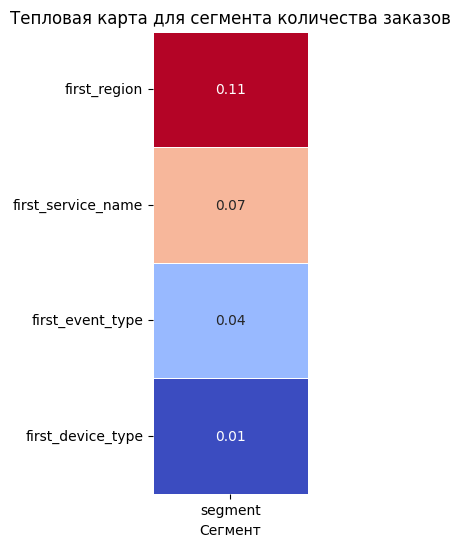

In [79]:
cols_target = ['first_device_type', 'first_region', 'first_service_name', 'first_event_type', 'segment']
corr_target = corr_subset[cols_target].copy()

phi_matrix_target = corr_target.phik_matrix()

corr_with_segment = phi_matrix_target.loc[phi_matrix_target.index != 'segment', 'segment'].sort_values(ascending=False)
print("Корреляция между признаками профиля и сегментом количества заказов")
print(corr_with_segment)

# Тепловая карта
plt.figure(figsize=(2, 6))
data_heatmap = phi_matrix_target['segment'].drop('segment').sort_values(ascending=False)
sns.heatmap(data_heatmap.to_frame(),
            annot=True,
            fmt='.2f',
            cmap='coolwarm',
            linewidths=0.5,
            cbar=False)
plt.title('Тепловая карта для сегмента количества заказов')
plt.xlabel('Сегмент')
plt.show()


Вывод:
* анализ показал, что с числом покупок очень слабо связаны параметры профиля пользователя.
* пользователи соверашают заказы по какой-то другой причине, вне зависимости от того с какого устройства делается заказ, на какое мероприятие они собираются идти, у какого оператора покупают и в каком регионе.

<a id="section5"></a>
### 5. Общий вывод и рекомендации

В конце проекта напишите общий вывод и рекомендации: расскажите заказчику, на что нужно обратить внимание. В выводах кратко укажите:

- **Информацию о данных**, с которыми вы работали, и то, как они были подготовлены: например, расскажите о фильтрации данных, переводе тенге в рубли, фильтрации выбросов.
- **Основные результаты анализа.** Например, укажите:
    - Сколько пользователей в выборке? Как распределены пользователи по числу заказов? Какие ещё статистические показатели вы подсчитали важным во время изучения данных?
    - Какие признаки первого заказа связаны с возвратом пользователей?
    - Как связаны средняя выручка и количество билетов в заказе с вероятностью повторных покупок?
    - Какие временные характеристики влияют на удержание (день недели, интервалы между покупками)?
    - Какие характеристики первого заказа и профиля пользователя могут быть связаны с числом покупок согласно результатам корреляционного анализа?
- Дополните выводы информацией, которая покажется вам важной и интересной. Следите за общим объёмом выводов — они должны быть компактными и ёмкими.

В конце предложите заказчику рекомендации о том, как именно действовать в его ситуации. Например, укажите, на какие сегменты пользователей стоит обратить внимание в первую очередь, а какие нуждаются в дополнительных маркетинговых усилиях.

Общие выводы:
* Первоначальный датасет содержал 290611 заказов по типам устройств "mobile" и "desktop" и всем мероприятиям, исключая фильмы 
* На этапе предобработки данных все заказы, которые были сделаны в тенге были приведены к рублям в соответствии с курсами валюты 1 рубль за 100 тенге. Результатом стало новое поле "revenue_rub".
* Данные были приведены к необходимым типам
* Пропущенные значение содержались только в столбце "days_since_prev" (количество дней между заказами). Фактически такие пропуски означали, что пользователь совершил всего один заказ и более не возвращался. Процент пропусков составил 7,55% от всего датасета.
* При предобробатке данных были обнаружены выбросы в поле "revenue_rub" (выручка в рублях). Данные были отфильтрованы по 99 перцентилю, тем самыми выбросы были нивелированы, а общее количество данных уменьшилось на 1,87% и составило 285178 заказов
* Далее был составлен датафрейм для последующего анализа профиля пользователя - предобработанный датафрейм был сгруппирован по уникальному идентификатору пользователя, посчитаны дополнительные столбцы показывающие сколько заказов совершил пользователь, какой был первый тип устройства, регион первого заказа, первый билетный оператор, первый тип мероприятия, первый и последний заказ по дате, а также вспомогательные столбцы показывающие совершил ли пользователь 2 и более заказа, а также совершил ли он 5 и более заказов
* Датафрейм по пользователям составил 21642 пользователя. В этом датафрейме были обнаружены выбросы в части анамально высокого количества заказов (max 10138). Для дальнейшего анализа, данные были отфильтрованы по 95 перцентилю. Таким образом, в итоговом датафрейме для сосатвления профиля пользователей осталось 20585 пользователей.
* При составлении профиля пользователя были использованы признаки: "Тип мероприятия", "Тип устройства", "Регион", "Билетный оператор". Анализ по данным признакам показал, что пользователи чаще делали заказы на "концерт" (43%) с "мобильного устройства" (83%) в районе "Каменевсий" (33%) у оператора "Билеты без проблем" (25%). Среди других типов мероприятий можно выделить "другое" (29%) и театр (20%). Регионы - "североярская область" (18%) и "широковская область" (6%). Среди билетных операторов так же выделялись "лови билет!", "мой билет", "билеты в руки" и "Облачко" - у каждого из них в среднем около 12% заказов
* Анализ по повторным заказам практически не изменил общую картину. Повторные заказы в основной массе так же осуществлясь на концерты с мобильного устройства в каменевском районе у оператора "билеты без проблем". 
анализ средней выручки по повторным заказам показал, что пользователи больше тратят на повторные заказы, чем на первые. Так, выручка по первым заказам концентрируется от 100 до 500 рублей, а на повторных до 1000 рублей.
* Анализ количества покупаемых пользователями билетов по повторным заказам показал, что 71%  это покупка 2-3 билетов. То есть почти три из четырех таких пользоватлей возвращаются за новыми покупками. А вот среди пользователей, которые покупают 3-5 билетов только половина возвращается за повторной покупкой.
макимальная доля возрата за покупками прихолится на понедельник (61,33%), минимальная на воскресенье (58,13%). Однако в целом развница не очень большая - день недели не является ключевым фактором совершения повторных заказов.
* Корреляционный анализ показал, что нет прямой зависимости числа заказов ни с типом мероприятия, ни с регионом, ни с устройством, ни с выбором билетного оператора. Пользователи совершают заказы по иным причинам.

В качестве рекомендаций - отделу маркетинга стоит обратить внимание на польщователей, которые покупают более 5 заказов, но при этом процент тех, кто возаращается за повторным заказом всего 19%. Так же стоит обратить внимание на регионы продаж билетов - всего в 2 регионов из 81 приходится составляют доля повторных заказов более 50%. Возможно, что в других регионах не так хорошо известен сервис по продаже билетов. так же стомит обратить внимание, что профиль пользователя первого заказа и повторного не отличаются. 
